# Step 0: Import Libraries and Prepared Data

In this notebook, we will use the already prepared feature-engineered data.

No feature engineering will be done here.

We will only:
1. import required libraries  
2. load prepared train/test files  
3. check shape and missing values  
4. prepare data for model training

In [4]:
# Step 0.1: Import required libraries

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Step 0.2: Set prepared data directory

DATA_PATH = Path(
    r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\Ames-Price-Regression\Research\prepared_data"
)

X_train_path = DATA_PATH / "X_train_prepared.csv"
X_test_path = DATA_PATH / "X_test_prepared.csv"
y_train_path = DATA_PATH / "y_train.csv"
y_train_log_path = DATA_PATH / "y_train_log1p.csv"
test_ids_path = DATA_PATH / "test_ids.csv"

required_files = {
    "X_train_prepared.csv": X_train_path,
    "X_test_prepared.csv": X_test_path,
    "y_train.csv": y_train_path,
    "y_train_log1p.csv": y_train_log_path,
    "test_ids.csv": test_ids_path
}

for file_name, file_path in required_files.items():
    if file_path.exists():
        print(f"Found: {file_name}")
    else:
        print(f"Missing: {file_name}")

Found: X_train_prepared.csv
Found: X_test_prepared.csv
Found: y_train.csv
Found: y_train_log1p.csv
Found: test_ids.csv


In [6]:
# Step 0.3: Load prepared data

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

y_train = pd.read_csv(y_train_path).iloc[:, 0]
y_train_log = pd.read_csv(y_train_log_path).iloc[:, 0]

test_ids = pd.read_csv(test_ids_path).iloc[:, 0]

print("Prepared data loaded successfully.")

Prepared data loaded successfully.


In [7]:
# Step 0.4: Check loaded data

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_train_log shape:", y_train_log.shape)
print("test_ids shape:", test_ids.shape)

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print("Infinite values in X_train:", np.isinf(X_train).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test).sum().sum())

if list(X_train.columns) == list(X_test.columns):
    print("Train and test columns are matched.")
else:
    print("Train and test columns are not matched.")

target = y_train_log.copy()

print("Data is ready for model training.")
print("Total features:", X_train.shape[1])
print("Total training rows:", X_train.shape[0])

X_train shape: (1458, 199)
X_test shape: (1459, 199)
y_train shape: (1458,)
y_train_log shape: (1458,)
test_ids shape: (1459,)
Missing values in X_train: 0
Missing values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0
Train and test columns are matched.
Data is ready for model training.
Total features: 199
Total training rows: 1458


# Step 1: Decision Tree Baseline Model

In this step, we will train a Decision Tree Regressor as a baseline model.

Important rule for this model:

1. Training will use log1p(SalePrice).
2. Evaluation will also use log1p(SalePrice).
3. MSE, RMSE, MAE, and R2 will be calculated on log1p(SalePrice).
4. Only the final prediction plot will use normal SalePrice.
5. Normal SalePrice will be created using np.expm1().

In [26]:
# Step 1.1: Import Decision Tree libraries

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Decision Tree libraries imported successfully.")

Decision Tree libraries imported successfully.


## Step 1.2: Split Data

We will split the prepared data into training and validation parts.

Here, y_train_log is the main target.

y_train will only be kept for plotting original SalePrice later.

In [27]:
# Step 1.2: Split data

X_train_part, X_valid, y_train_log_part, y_valid_log, y_train_original_part, y_valid_original = train_test_split(
    X_train,
    y_train_log,
    y_train,
    test_size=0.20,
    random_state=42
)

print("X_train_part shape:", X_train_part.shape)
print("X_valid shape:", X_valid.shape)
print("y_train_log_part shape:", y_train_log_part.shape)
print("y_valid_log shape:", y_valid_log.shape)
print("y_valid_original shape:", y_valid_original.shape)

X_train_part shape: (1166, 199)
X_valid shape: (292, 199)
y_train_log_part shape: (1166,)
y_valid_log shape: (292,)
y_valid_original shape: (292,)


## Step 1.3: Train Decision Tree Baseline

A Decision Tree can overfit easily.

So, we will search a few parameter values and select the best tree using validation-friendly cross-validation.

The scoring is RMSE on log1p(SalePrice).

In [28]:
# Step 1.3: Tune and train Decision Tree baseline model

decision_tree = DecisionTreeRegressor(random_state=42)

param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10, 12],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [None, "sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_part, y_train_log_part)

best_decision_tree_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE on log1p(SalePrice):", -grid_search.best_score_)

Best parameters:
{'max_depth': 8, 'max_features': None, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV RMSE on log1p(SalePrice): 0.1632408613257421


## Step 1.4: Predict Validation Data

The model will predict log1p(SalePrice).

For evaluation, we will keep prediction in log scale.

For plotting, we will convert prediction back to normal SalePrice.

In [29]:
# Step 1.4: Predict validation data

y_valid_pred_log = best_decision_tree_model.predict(X_valid)

y_valid_pred_original = np.expm1(y_valid_pred_log)
y_valid_true_original = y_valid_original.copy()

print("Prediction completed.")

Prediction completed.


## Step 1.5: Evaluate Model on log1p(SalePrice)

Here all evaluation metrics are calculated using log1p(SalePrice).

This is better for Ames house price prediction because SalePrice is highly skewed.

In [30]:
# Step 1.5: Evaluate Decision Tree using log1p(SalePrice)

mse_log = mean_squared_error(y_valid_log, y_valid_pred_log)
rmse_log = np.sqrt(mse_log)
mae_log = mean_absolute_error(y_valid_log, y_valid_pred_log)
r2_log = r2_score(y_valid_log, y_valid_pred_log)

decision_tree_baseline_summary = pd.DataFrame({
    "Model": ["Decision Tree Baseline"],
    "MSE_log1p": [mse_log],
    "RMSE_log1p": [rmse_log],
    "MAE_log1p": [mae_log],
    "R2_log1p": [r2_log]
})

decision_tree_baseline_summary

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Decision Tree Baseline,0.02856,0.168997,0.122934,0.830581


## Step 1.6: Check True and Predicted Values

This table shows both log prediction and normal SalePrice prediction.

Evaluation is done on log1p(SalePrice).

Normal SalePrice is shown only for easier understanding.

In [31]:
# Step 1.6: Create prediction comparison table

decision_tree_results = pd.DataFrame({
    "True_log1p_SalePrice": y_valid_log.values,
    "Predicted_log1p_SalePrice": y_valid_pred_log,
    "True_SalePrice": y_valid_true_original.values,
    "Predicted_SalePrice": y_valid_pred_original
})

decision_tree_results["Log_Error"] = (
    decision_tree_results["True_log1p_SalePrice"] 
    - decision_tree_results["Predicted_log1p_SalePrice"]
)

decision_tree_results["Absolute_Log_Error"] = decision_tree_results["Log_Error"].abs()

decision_tree_results.head(10)

,True_log1p_SalePrice,Predicted_log1p_SalePrice,True_SalePrice,Predicted_SalePrice,Log_Error,Absolute_Log_Error
0,12.154785,12.255540,190000,210141.185471,-0.100755,0.100755
1,11.512935,11.364173,100000,86177.205303,0.148763,0.148763
2,11.652696,11.698397,115000,120377.649559,-0.045701,0.045701
3,11.976666,11.925005,159000,150994.488453,0.051661,0.051661
4,12.661917,12.714540,315500,332547.302299,-0.052623,0.052623
5,11.831386,11.911978,137500,149040.235643,-0.080592,0.080592
6,12.649158,12.098112,311500,179531.553448,0.551046,0.551046
7,12.644331,12.752952,310000,345569.406418,-0.108621,0.108621
8,12.546114,12.505023,281000,269687.626161,0.041090,0.041090
9,11.816734,11.951585,135500,155061.750741,-0.134851,0.134851


## Step 1.7: Plot Decision Tree

This plot shows how the Decision Tree makes decisions.

Only the first few levels are shown to keep the plot readable.

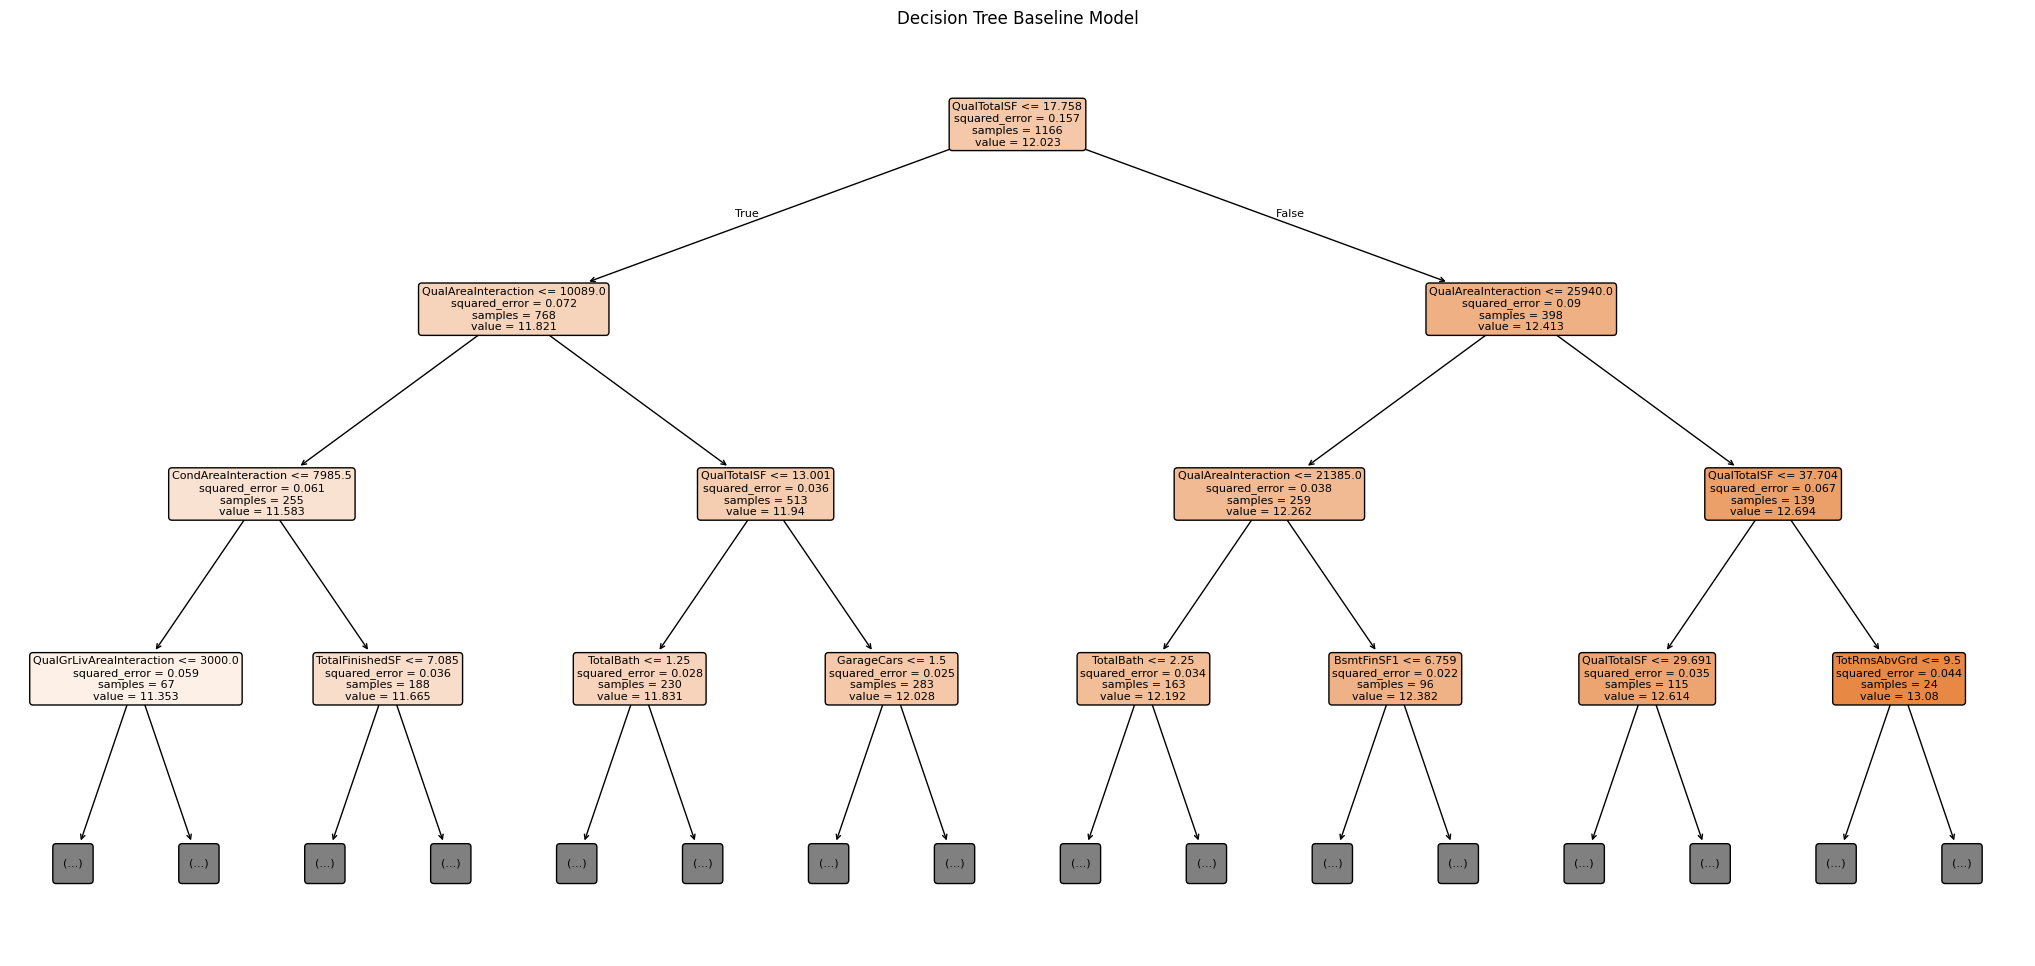

In [32]:
# Step 1.7: Plot Decision Tree

plt.figure(figsize=(26, 12))

plot_tree(
    best_decision_tree_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Baseline Model")
plt.show()

## Step 1.8: Plot Predicted SalePrice vs True SalePrice

This plot uses normal SalePrice, not log1p(SalePrice).

Good predictions should stay close to the diagonal line.

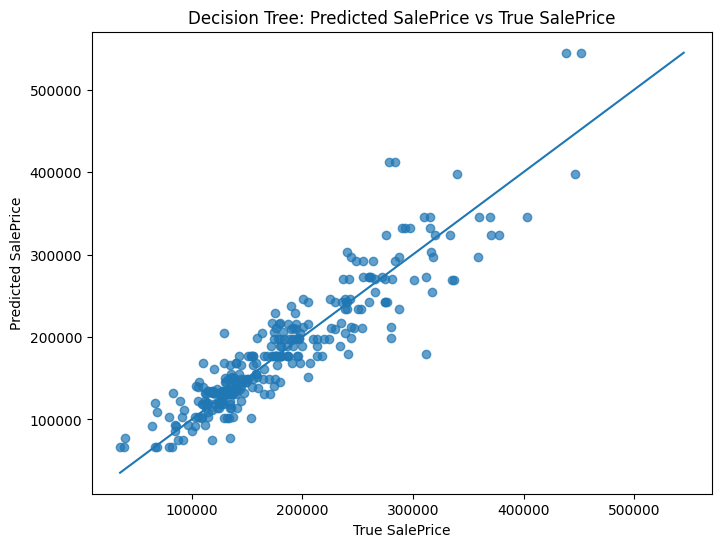

In [33]:
# Step 1.8: Plot Predicted SalePrice vs True SalePrice

plt.figure(figsize=(8, 6))

plt.scatter(
    y_valid_true_original,
    y_valid_pred_original,
    alpha=0.7
)

min_price = min(y_valid_true_original.min(), y_valid_pred_original.min())
max_price = max(y_valid_true_original.max(), y_valid_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Decision Tree: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 1.9: Feature Importance

This plot shows the most important features used by the Decision Tree.

Higher importance means the feature helped more in prediction.

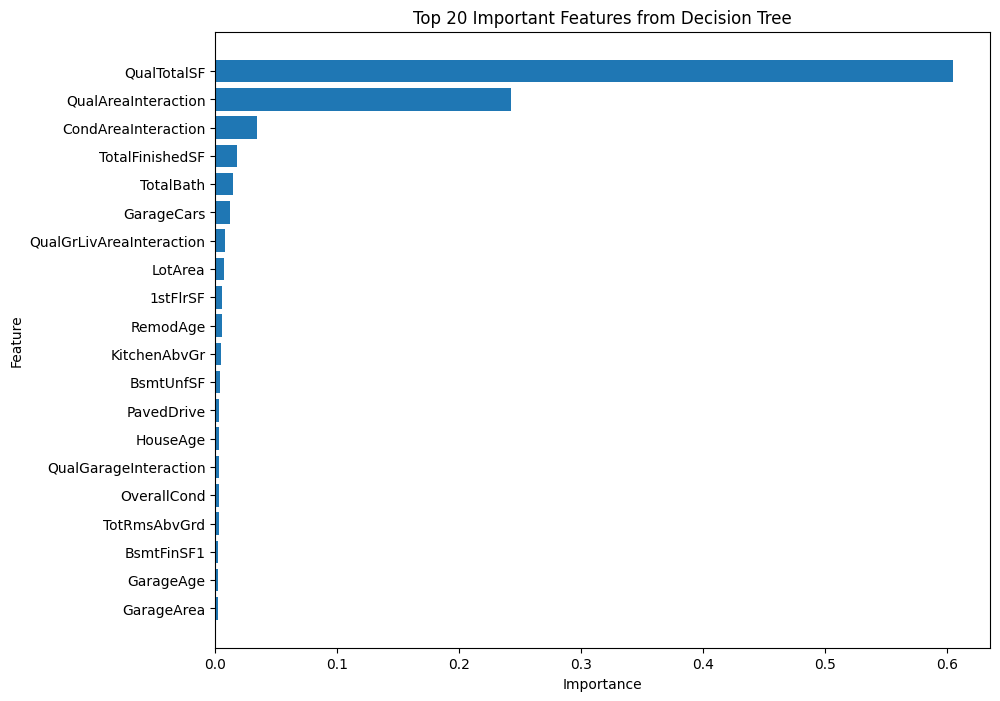

In [34]:
# Step 1.9: Plot feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from Decision Tree")
plt.show()

## Step 1.10: Final Decision Tree Baseline Result

This is the final Decision Tree baseline result.

All metrics are based on log1p(SalePrice).

In [35]:
# Step 1.10: Final baseline result

print("Decision Tree Baseline Performance on log1p(SalePrice)")
print("MSE_log1p:", mse_log)
print("RMSE_log1p:", rmse_log)
print("MAE_log1p:", mae_log)
print("R2_log1p:", r2_log)

decision_tree_baseline_summary

Decision Tree Baseline Performance on log1p(SalePrice)
MSE_log1p: 0.02856010304082034
RMSE_log1p: 0.168997346253781
MAE_log1p: 0.12293446846224255
R2_log1p: 0.830580519576732


,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Decision Tree Baseline,0.02856,0.168997,0.122934,0.830581


# Step 2: Linear Models

In this step, we will train four linear models:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression

All model training and evaluation will use log1p(SalePrice).

Only the prediction plots will use normal SalePrice by converting log prediction with np.expm1().

In [36]:
# Step 2.0: Import linear model libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Linear model libraries imported successfully.")

Linear model libraries imported successfully.


In [37]:
# Step 2.0.1: Create train and validation data for linear models

X_train_part, X_valid, y_train_log_part, y_valid_log, y_train_original_part, y_valid_original = train_test_split(
    X_train,
    y_train_log,
    y_train,
    test_size=0.20,
    random_state=42
)

print("X_train_part shape:", X_train_part.shape)
print("X_valid shape:", X_valid.shape)
print("y_train_log_part shape:", y_train_log_part.shape)
print("y_valid_log shape:", y_valid_log.shape)

X_train_part shape: (1166, 199)
X_valid shape: (292, 199)
y_train_log_part shape: (1166,)
y_valid_log shape: (292,)


In [38]:
# Step 2.0.2: Helper function for evaluation

def evaluate_log_model(model_name, y_true_log, y_pred_log):
    mse_log = mean_squared_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    
    result = pd.DataFrame({
        "Model": [model_name],
        "MSE_log1p": [mse_log],
        "RMSE_log1p": [rmse_log],
        "MAE_log1p": [mae_log],
        "R2_log1p": [r2_log]
    })
    
    return result

## Step 2.1: Linear Regression

Linear Regression is the simplest linear model.

It tries to find a straight-line relationship between the features and log1p(SalePrice).

This model does not use regularization.

In [39]:
# Step 2.1.1: Train Linear Regression model

linear_regression_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_regression_model.fit(X_train_part, y_train_log_part)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [40]:
# Step 2.1.2: Predict and evaluate Linear Regression

linear_pred_log = linear_regression_model.predict(X_valid)

linear_result = evaluate_log_model(
    "Linear Regression",
    y_valid_log,
    linear_pred_log
)

linear_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Linear Regression,0.015576,0.124804,0.08237,0.907603


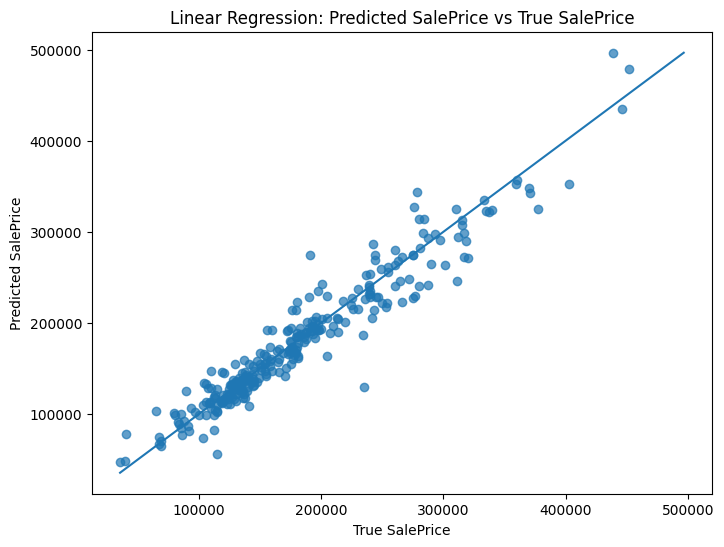

In [41]:
# Step 2.1.3: Plot Linear Regression predicted SalePrice vs true SalePrice

linear_pred_original = np.expm1(linear_pred_log)
linear_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    linear_true_original,
    linear_pred_original,
    alpha=0.7
)

min_price = min(linear_true_original.min(), linear_pred_original.min())
max_price = max(linear_true_original.max(), linear_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 2.2: Ridge Regression

Ridge Regression is a regularized linear model.

It helps reduce overfitting by shrinking large coefficients.

We will tune the alpha value using cross-validation.

In [42]:
# Step 2.2.1: Tune and train Ridge Regression model

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=42))
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train_part, y_train_log_part)

best_ridge_model = ridge_grid.best_estimator_

print("Best Ridge parameters:")
print(ridge_grid.best_params_)
print("Best CV RMSE on log1p(SalePrice):", -ridge_grid.best_score_)

Best Ridge parameters:
{'model__alpha': 100}
Best CV RMSE on log1p(SalePrice): 0.11306951745709878


In [43]:
# Step 2.2.2: Predict and evaluate Ridge Regression

ridge_pred_log = best_ridge_model.predict(X_valid)

ridge_result = evaluate_log_model(
    "Ridge Regression",
    y_valid_log,
    ridge_pred_log
)

ridge_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Ridge Regression,0.014523,0.120512,0.080816,0.913849


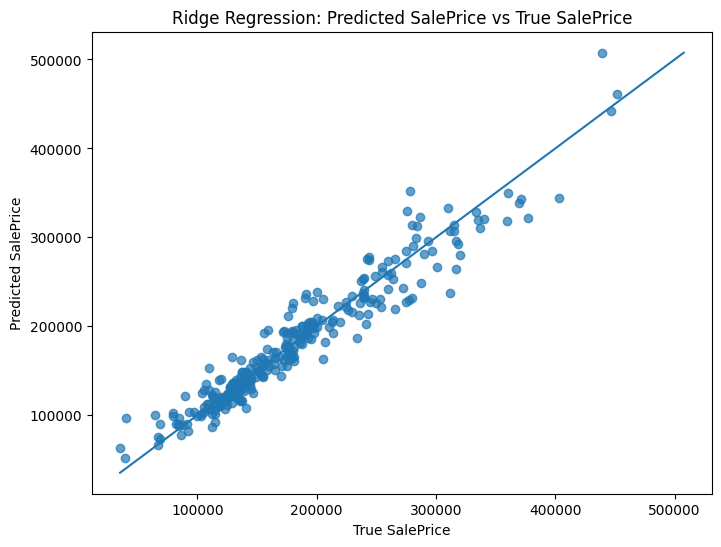

In [44]:
# Step 2.2.3: Plot Ridge predicted SalePrice vs true SalePrice

ridge_pred_original = np.expm1(ridge_pred_log)
ridge_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    ridge_true_original,
    ridge_pred_original,
    alpha=0.7
)

min_price = min(ridge_true_original.min(), ridge_pred_original.min())
max_price = max(ridge_true_original.max(), ridge_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Ridge Regression: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 2.3: Lasso Regression

Lasso Regression is another regularized linear model.

It can reduce some feature coefficients to zero.

This means it can also work like feature selection.

In [45]:
# Step 2.3.1: Tune and train Lasso Regression model

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(random_state=42, max_iter=30000))
])

lasso_param_grid = {
    "model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train_part, y_train_log_part)

best_lasso_model = lasso_grid.best_estimator_

print("Best Lasso parameters:")
print(lasso_grid.best_params_)
print("Best CV RMSE on log1p(SalePrice):", -lasso_grid.best_score_)

Best Lasso parameters:
{'model__alpha': 0.0003}
Best CV RMSE on log1p(SalePrice): 0.11294890367797365


In [46]:
# Step 2.3.2: Predict and evaluate Lasso Regression

lasso_pred_log = best_lasso_model.predict(X_valid)

lasso_result = evaluate_log_model(
    "Lasso Regression",
    y_valid_log,
    lasso_pred_log
)

lasso_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Lasso Regression,0.014095,0.118721,0.080218,0.91639


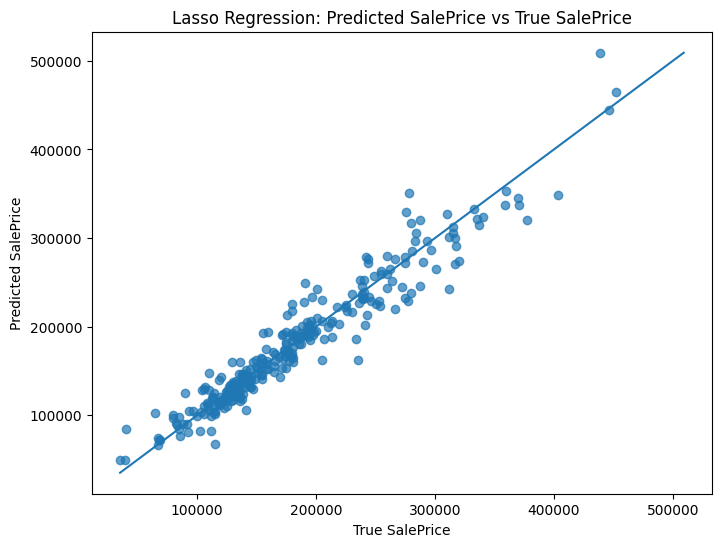

In [47]:
# Step 2.3.3: Plot Lasso predicted SalePrice vs true SalePrice

lasso_pred_original = np.expm1(lasso_pred_log)
lasso_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    lasso_true_original,
    lasso_pred_original,
    alpha=0.7
)

min_price = min(lasso_true_original.min(), lasso_pred_original.min())
max_price = max(lasso_true_original.max(), lasso_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Lasso Regression: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 2.4: ElasticNet Regression

ElasticNet combines Ridge and Lasso regularization.

It uses two important parameters:

1. alpha controls regularization strength
2. l1_ratio controls the balance between Ridge and Lasso

In [48]:
# Step 2.4.1: Tune and train ElasticNet Regression model

elasticnet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(random_state=42, max_iter=30000))
])

elasticnet_param_grid = {
    "model__alpha": [0.0001, 0.0003, 0.0005, 0.001, 0.003, 0.005, 0.01],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_grid = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=elasticnet_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

elasticnet_grid.fit(X_train_part, y_train_log_part)

best_elasticnet_model = elasticnet_grid.best_estimator_

print("Best ElasticNet parameters:")
print(elasticnet_grid.best_params_)
print("Best CV RMSE on log1p(SalePrice):", -elasticnet_grid.best_score_)

Best ElasticNet parameters:
{'model__alpha': 0.0005, 'model__l1_ratio': 0.9}
Best CV RMSE on log1p(SalePrice): 0.11286201858150353


In [49]:
# Step 2.4.2: Predict and evaluate ElasticNet Regression

elasticnet_pred_log = best_elasticnet_model.predict(X_valid)

elasticnet_result = evaluate_log_model(
    "ElasticNet Regression",
    y_valid_log,
    elasticnet_pred_log
)

elasticnet_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,ElasticNet Regression,0.013649,0.116829,0.079474,0.919034


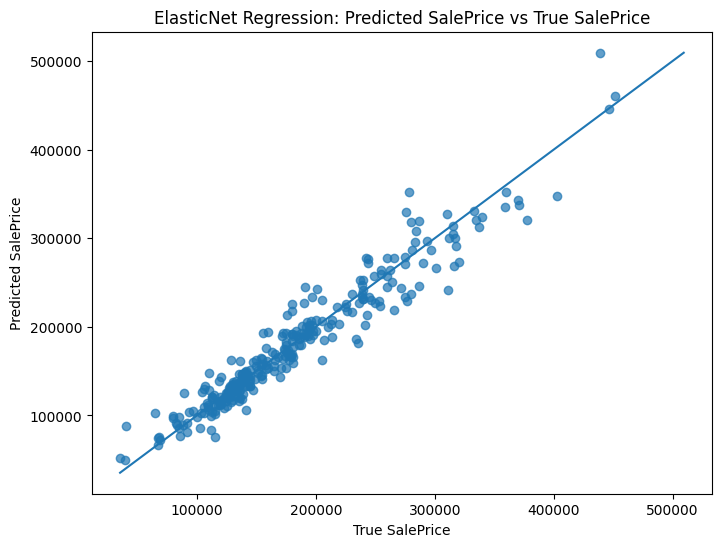

In [50]:
# Step 2.4.3: Plot ElasticNet predicted SalePrice vs true SalePrice

elasticnet_pred_original = np.expm1(elasticnet_pred_log)
elasticnet_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    elasticnet_true_original,
    elasticnet_pred_original,
    alpha=0.7
)

min_price = min(elasticnet_true_original.min(), elasticnet_pred_original.min())
max_price = max(elasticnet_true_original.max(), elasticnet_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("ElasticNet Regression: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 2.5: Compare Linear Models

Now we will compare all four linear models.

The best model should have lower RMSE_log1p and higher R2_log1p.

In [51]:
# Step 2.5.1: Compare all linear model results

linear_models_summary = pd.concat(
    [
        linear_result,
        ridge_result,
        lasso_result,
        elasticnet_result
    ],
    ignore_index=True
)

linear_models_summary = linear_models_summary.sort_values(
    by="RMSE_log1p",
    ascending=True
)

linear_models_summary

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
3,ElasticNet Regression,0.013649,0.116829,0.079474,0.919034
2,Lasso Regression,0.014095,0.118721,0.080218,0.916390
1,Ridge Regression,0.014523,0.120512,0.080816,0.913849
0,Linear Regression,0.015576,0.124804,0.082370,0.907603


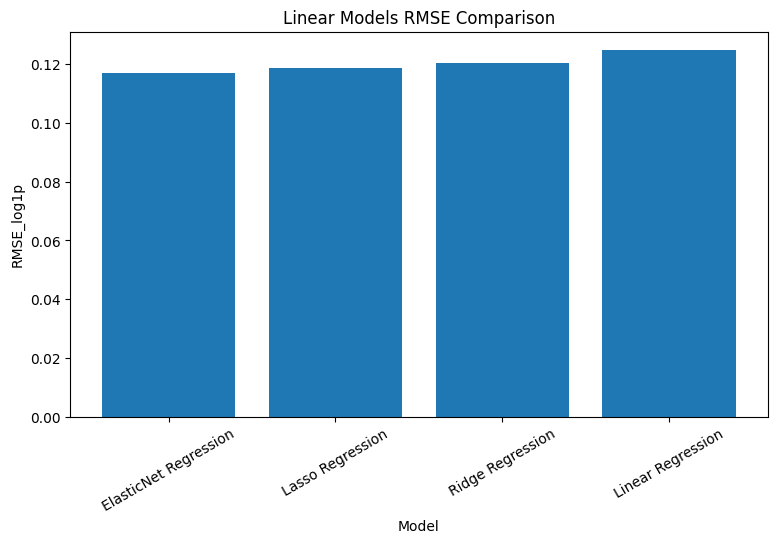

In [52]:
# Step 2.5.2: Plot linear model RMSE comparison

plt.figure(figsize=(9, 5))

plt.bar(
    linear_models_summary["Model"],
    linear_models_summary["RMSE_log1p"]
)

plt.xlabel("Model")
plt.ylabel("RMSE_log1p")
plt.title("Linear Models RMSE Comparison")
plt.xticks(rotation=30)
plt.show()

# Step 3: Random Forest Regressor

In this step, we will train Random Forest models.

We will use two versions:

1. Step 3.1: Random Forest Regressor using all prepared features
2. Step 3.2: Random Forest Regressor using ElasticNet selected features

No boosting model will be used here.

All evaluation metrics will be calculated using log1p(SalePrice).

Only the prediction plots will use normal SalePrice.

In [53]:
# Step 3.0: Import Random Forest libraries

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Random Forest libraries imported successfully.")

Random Forest libraries imported successfully.


In [54]:
# Step 3.0.1: Create train and validation data for Random Forest

X_train_part, X_valid, y_train_log_part, y_valid_log, y_train_original_part, y_valid_original = train_test_split(
    X_train,
    y_train_log,
    y_train,
    test_size=0.20,
    random_state=42
)

print("X_train_part shape:", X_train_part.shape)
print("X_valid shape:", X_valid.shape)
print("y_train_log_part shape:", y_train_log_part.shape)
print("y_valid_log shape:", y_valid_log.shape)

X_train_part shape: (1166, 199)
X_valid shape: (292, 199)
y_train_log_part shape: (1166,)
y_valid_log shape: (292,)


In [55]:
# Step 3.0.2: Helper function for Random Forest evaluation

def evaluate_random_forest_model(model_name, y_true_log, y_pred_log):
    mse_log = mean_squared_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    
    result = pd.DataFrame({
        "Model": [model_name],
        "MSE_log1p": [mse_log],
        "RMSE_log1p": [rmse_log],
        "MAE_log1p": [mae_log],
        "R2_log1p": [r2_log]
    })
    
    return result

## Step 3.1: Random Forest Regressor with Decision Trees

Random Forest is made from many Decision Trees.

Each tree learns from a different random part of the data.

Then all trees work together to make the final prediction.

This model will use all prepared features.

In [56]:
# Step 3.1.1: Tune and train Random Forest using all features

random_forest_all = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_all_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

rf_all_search = RandomizedSearchCV(
    estimator=random_forest_all,
    param_distributions=rf_all_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_all_search.fit(X_train_part, y_train_log_part)

best_rf_all_model = rf_all_search.best_estimator_

print("Best Random Forest parameters:")
print(rf_all_search.best_params_)
print("Best CV RMSE on log1p(SalePrice):", -rf_all_search.best_score_)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV RMSE on log1p(SalePrice): 0.13083288002377141


In [57]:
# Step 3.1.2: Predict and evaluate Random Forest using all features

rf_all_pred_log = best_rf_all_model.predict(X_valid)

rf_all_result = evaluate_random_forest_model(
    "Random Forest Regressor",
    y_valid_log,
    rf_all_pred_log
)

rf_all_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Random Forest Regressor,0.019256,0.138766,0.090267,0.885772


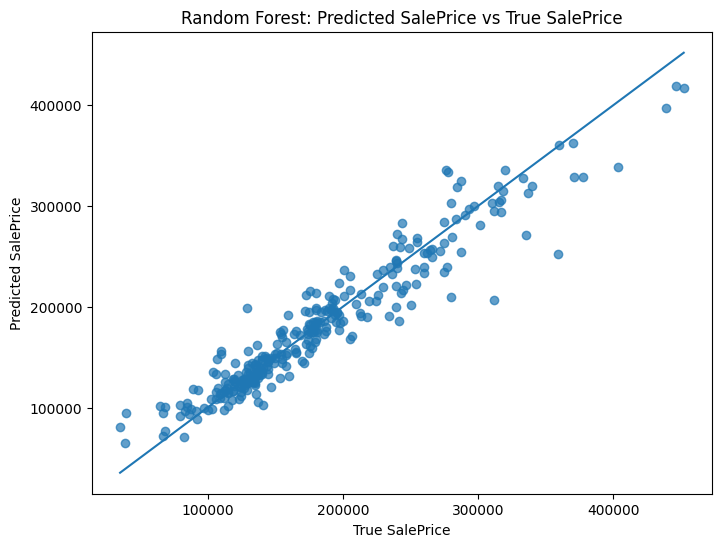

In [58]:
# Step 3.1.3: Plot Random Forest predicted SalePrice vs true SalePrice

rf_all_pred_original = np.expm1(rf_all_pred_log)
rf_all_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_all_true_original,
    rf_all_pred_original,
    alpha=0.7
)

min_price = min(rf_all_true_original.min(), rf_all_pred_original.min())
max_price = max(rf_all_true_original.max(), rf_all_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Random Forest: Predicted SalePrice vs True SalePrice")
plt.show()

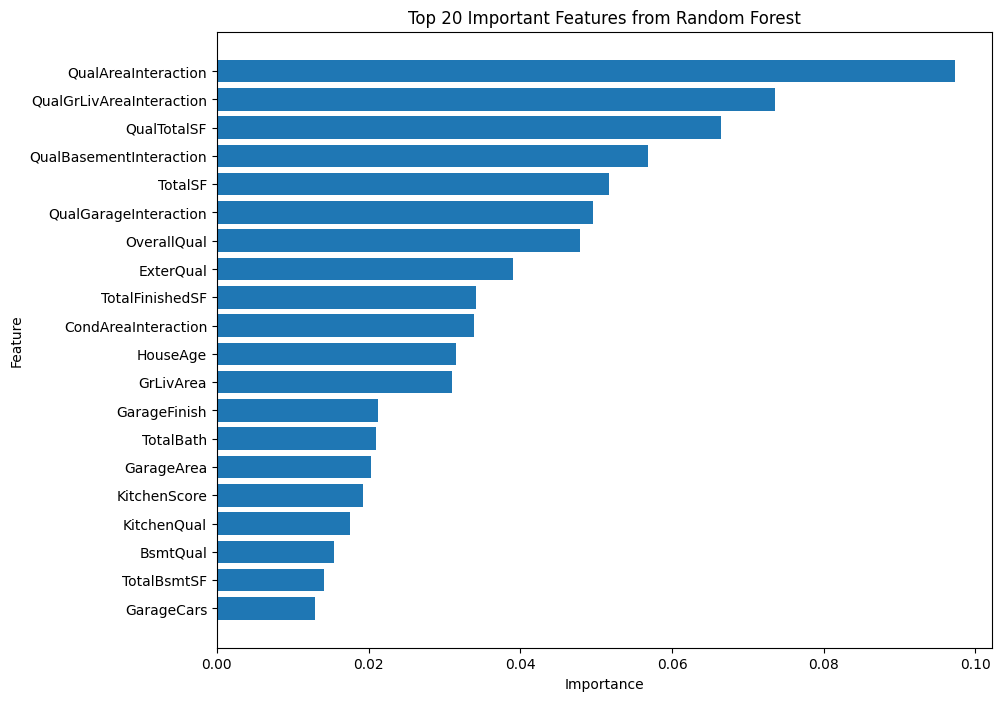

In [59]:
# Step 3.1.4: Plot top important features from Random Forest

rf_all_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_all_model.feature_importances_
})

rf_all_feature_importance = rf_all_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_rf_all_features = rf_all_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_rf_all_features["Feature"],
    top_rf_all_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from Random Forest")
plt.show()

## Step 3.2: Random Forest Regressor after ElasticNet

In this step, we will train another Random Forest Regressor.

Important:

1. No feature will be removed.
2. We will use all prepared features.
3. The model will train using log1p(SalePrice).
4. Evaluation will use log1p(SalePrice).
5. The final plot will use normal SalePrice.

In [74]:
# Step 3.2.1: Tune and train Random Forest Regressor

random_forest_elastic = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_elastic_param_grid = {
    "n_estimators": [300, 500, 800, 1000],
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 4, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2", 0.4, 0.5, 0.6, 0.7]
}

rf_elastic_search = RandomizedSearchCV(
    estimator=random_forest_elastic,
    param_distributions=rf_elastic_param_grid,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_elastic_search.fit(X_train_part, y_train_log_part)

best_rf_elastic_model = rf_elastic_search.best_estimator_

print("Best Random Forest parameters:")
print(rf_elastic_search.best_params_)
print("Best CV RMSE on log1p(SalePrice):", -rf_elastic_search.best_score_)

Best Random Forest parameters:
{'n_estimators': 500, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV RMSE on log1p(SalePrice): 0.1309359243093995


## Step 3.2.2: Predict Validation Data

Now we will predict validation data using the tuned Random Forest model.

Prediction will stay in log1p(SalePrice) scale for evaluation.

In [75]:
# Step 3.2.2: Predict validation data

rf_elastic_pred_log = best_rf_elastic_model.predict(X_valid)

print("Prediction completed.")

Prediction completed.


## Step 3.2.3: Evaluate Random Forest Regressor

All evaluation metrics are calculated using log1p(SalePrice).

In [76]:
# Step 3.2.3: Evaluate Random Forest Regressor

rf_elastic_result = evaluate_random_forest_model(
    "Random Forest Regressor after ElasticNet",
    y_valid_log,
    rf_elastic_pred_log
)

rf_elastic_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Random Forest Regressor after ElasticNet,0.019143,0.138359,0.09006,0.886442


## Step 3.2.4: Compare with ElasticNet

Here we compare Random Forest with the ElasticNet result from Step 2.

Lower RMSE_log1p means better performance.

In [77]:
# Step 3.2.4: Compare Random Forest with ElasticNet

elasticnet_vs_random_forest = pd.concat(
    [
        elasticnet_result,
        rf_elastic_result
    ],
    ignore_index=True
)

elasticnet_vs_random_forest = elasticnet_vs_random_forest.sort_values(
    by="RMSE_log1p",
    ascending=True
)

elasticnet_vs_random_forest

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,ElasticNet Regression,0.013649,0.116829,0.079474,0.919034
1,Random Forest Regressor after ElasticNet,0.019143,0.138359,0.090060,0.886442


## Step 3.2.5: Plot Predicted SalePrice vs True SalePrice

This plot uses normal SalePrice.

But the model evaluation is done using log1p(SalePrice).

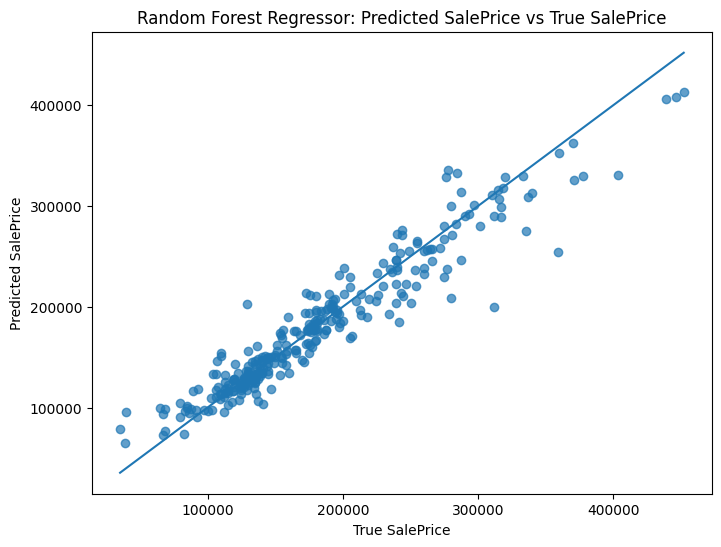

In [78]:
# Step 3.2.5: Plot predicted SalePrice vs true SalePrice

rf_elastic_pred_original = np.expm1(rf_elastic_pred_log)
rf_elastic_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    rf_elastic_true_original,
    rf_elastic_pred_original,
    alpha=0.7
)

min_price = min(
    rf_elastic_true_original.min(),
    rf_elastic_pred_original.min()
)

max_price = max(
    rf_elastic_true_original.max(),
    rf_elastic_pred_original.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Random Forest Regressor: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 3.2.6: Feature Importance

This plot shows the top important features used by Random Forest.

No feature was removed before training.

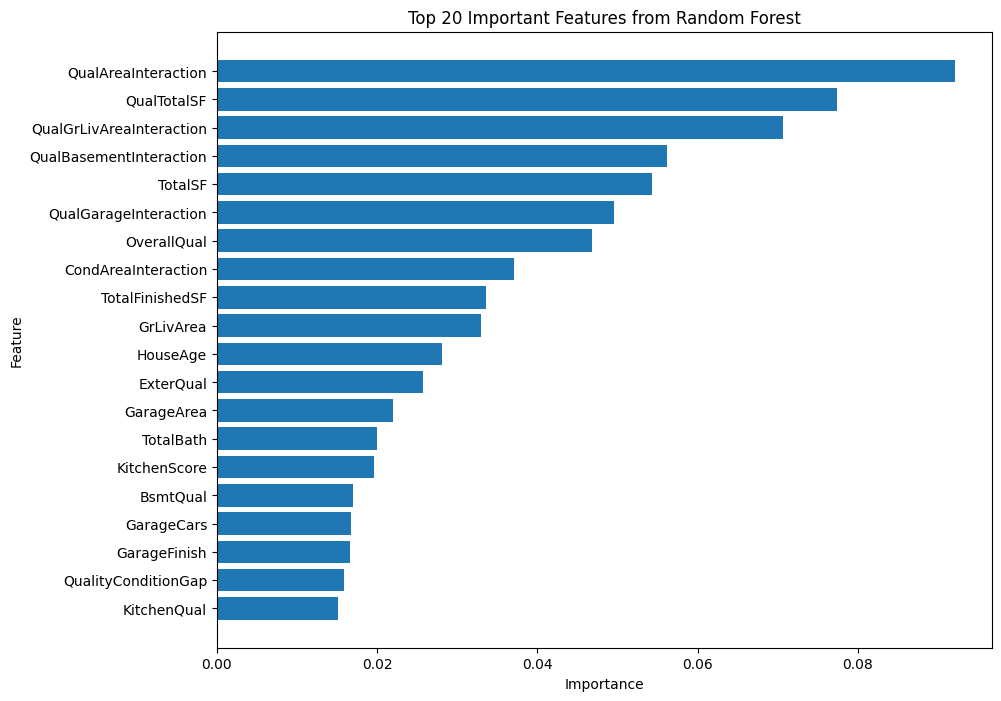

In [79]:
# Step 3.2.6: Plot feature importance

rf_elastic_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_elastic_model.feature_importances_
})

rf_elastic_feature_importance = rf_elastic_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_rf_elastic_features = rf_elastic_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_rf_elastic_features["Feature"],
    top_rf_elastic_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from Random Forest")
plt.show()

In [80]:
# Step 3.2.7: Final result

print("Random Forest Regressor Performance on log1p(SalePrice)")
print("MSE_log1p:", rf_elastic_result["MSE_log1p"].values[0])
print("RMSE_log1p:", rf_elastic_result["RMSE_log1p"].values[0])
print("MAE_log1p:", rf_elastic_result["MAE_log1p"].values[0])
print("R2_log1p:", rf_elastic_result["R2_log1p"].values[0])

rf_elastic_result

Random Forest Regressor Performance on log1p(SalePrice)
MSE_log1p: 0.019143194761094617
RMSE_log1p: 0.13835893451850018
MAE_log1p: 0.09006023660723834
R2_log1p: 0.8864419324597465


,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Random Forest Regressor after ElasticNet,0.019143,0.138359,0.09006,0.886442


# Step 4: Boosting Models

In this step, we will train boosting models.

Boosting models are stronger tree-based models.

They build many small trees one after another.

Each new tree tries to fix the mistakes of the previous trees.

Here we will use:

1. XGBoost Regressor
2. CatBoost Regressor

All evaluation metrics will be calculated using log1p(SalePrice).

Only prediction plots will use normal SalePrice.

In [81]:
# Step 4.0: Import boosting model libraries

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV

try:
    from xgboost import XGBRegressor
    print("XGBoost imported successfully.")
except ImportError:
    print("XGBoost is not installed. Run: pip install xgboost")

try:
    from catboost import CatBoostRegressor
    print("CatBoost imported successfully.")
except ImportError:
    print("CatBoost is not installed. Run: pip install catboost")

XGBoost imported successfully.
CatBoost imported successfully.


In [82]:
# Step 4.0.1: Evaluation function for boosting models

def evaluate_boosting_model(model_name, y_true_log, y_pred_log):
    mse_log = mean_squared_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)

    result = pd.DataFrame({
        "Model": [model_name],
        "MSE_log1p": [mse_log],
        "RMSE_log1p": [rmse_log],
        "MAE_log1p": [mae_log],
        "R2_log1p": [r2_log]
    })

    return result

## Step 4.1: XGBoost Regressor

XGBoost is a powerful boosting model.

It builds trees step by step.

Each new tree tries to reduce the previous prediction error.

This model will use all prepared features.

Evaluation will be done using log1p(SalePrice).

In [83]:
# Step 4.1.1: Train XGBoost Regressor

xgb_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.001,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_part,
    y_train_log_part,
    eval_set=[(X_valid, y_valid_log)],
    verbose=False
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [84]:
# Step 4.1.2: Predict and evaluate XGBoost

xgb_pred_log = xgb_model.predict(X_valid)

xgb_result = evaluate_boosting_model(
    "XGBoost Regressor",
    y_valid_log,
    xgb_pred_log
)

xgb_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,XGBoost Regressor,0.015252,0.123498,0.082461,0.909527


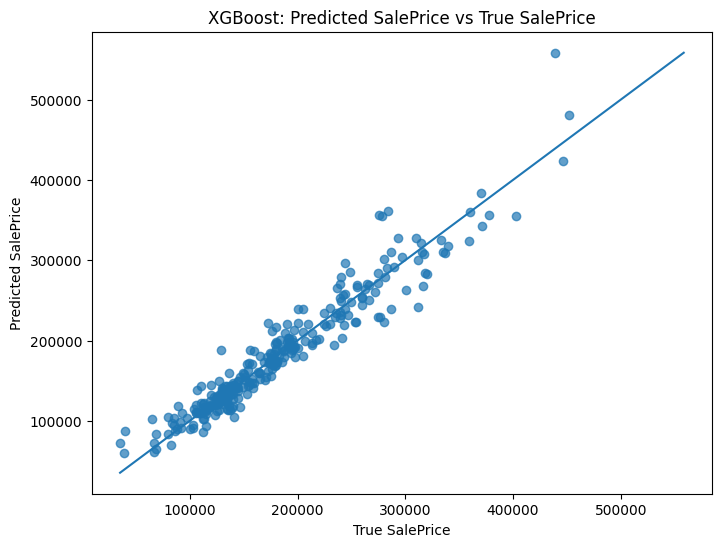

In [85]:
# Step 4.1.3: Plot XGBoost predicted SalePrice vs true SalePrice

xgb_pred_original = np.expm1(xgb_pred_log)
xgb_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    xgb_true_original,
    xgb_pred_original,
    alpha=0.7
)

min_price = min(xgb_true_original.min(), xgb_pred_original.min())
max_price = max(xgb_true_original.max(), xgb_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("XGBoost: Predicted SalePrice vs True SalePrice")
plt.show()

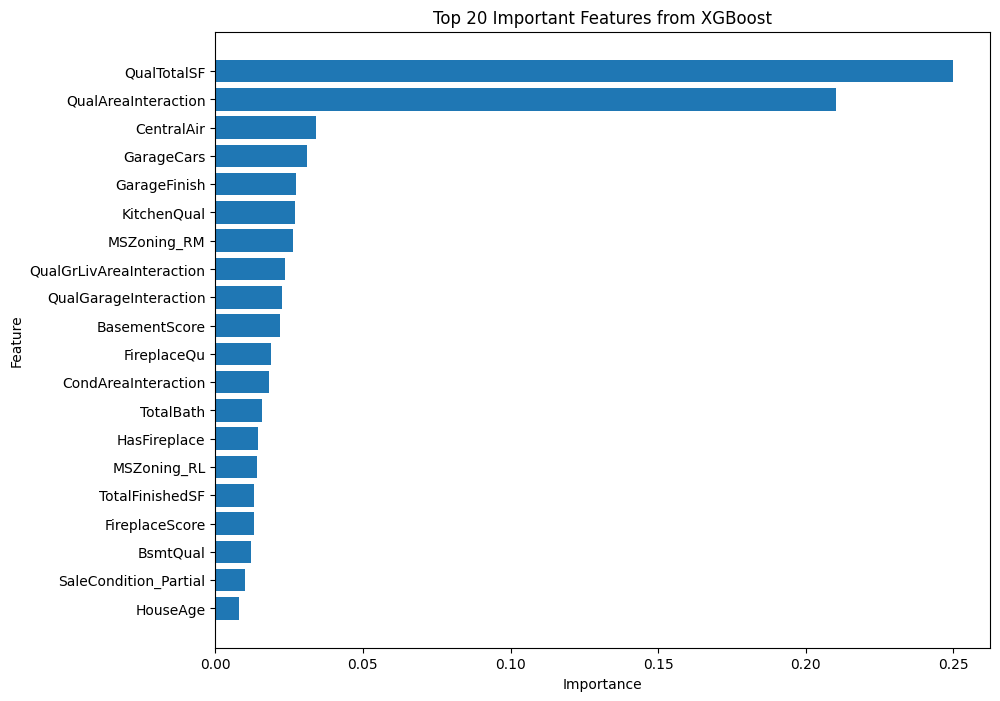

In [86]:
# Step 4.1.4: Plot XGBoost feature importance

xgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_xgb_features = xgb_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb_features["Feature"],
    top_xgb_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from XGBoost")
plt.show()

## Step 4.2: CatBoost Regressor

CatBoost is another strong boosting model.

It usually works well with tabular data.

Here all features are already prepared and numeric.

So, CatBoost can train directly on the prepared data.

Evaluation will be done using log1p(SalePrice).

In [87]:
# Step 4.2.1: Train CatBoost Regressor

catboost_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_part,
    y_train_log_part,
    eval_set=(X_valid, y_valid_log),
    use_best_model=True
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


In [88]:
# Step 4.2.2: Predict and evaluate CatBoost

catboost_pred_log = catboost_model.predict(X_valid)

catboost_result = evaluate_boosting_model(
    "CatBoost Regressor",
    y_valid_log,
    catboost_pred_log
)

catboost_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,CatBoost Regressor,0.01364,0.11679,0.076371,0.919088


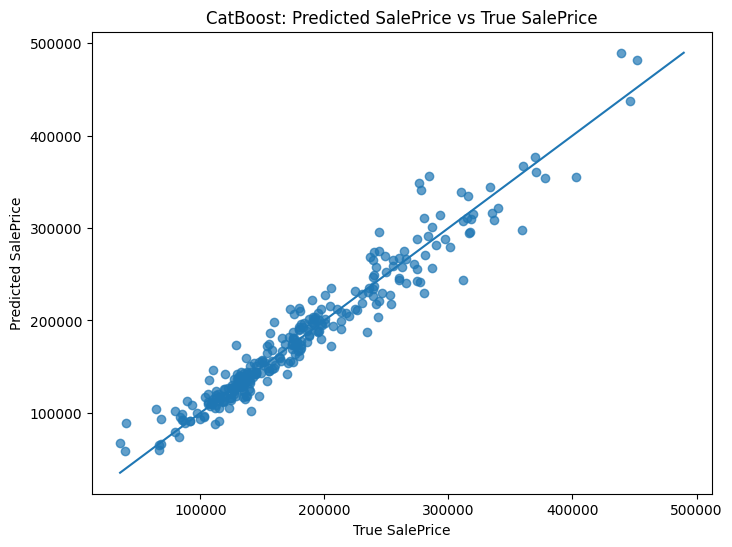

In [89]:
# Step 4.2.3: Plot CatBoost predicted SalePrice vs true SalePrice

catboost_pred_original = np.expm1(catboost_pred_log)
catboost_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    catboost_true_original,
    catboost_pred_original,
    alpha=0.7
)

min_price = min(catboost_true_original.min(), catboost_pred_original.min())
max_price = max(catboost_true_original.max(), catboost_pred_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("CatBoost: Predicted SalePrice vs True SalePrice")
plt.show()

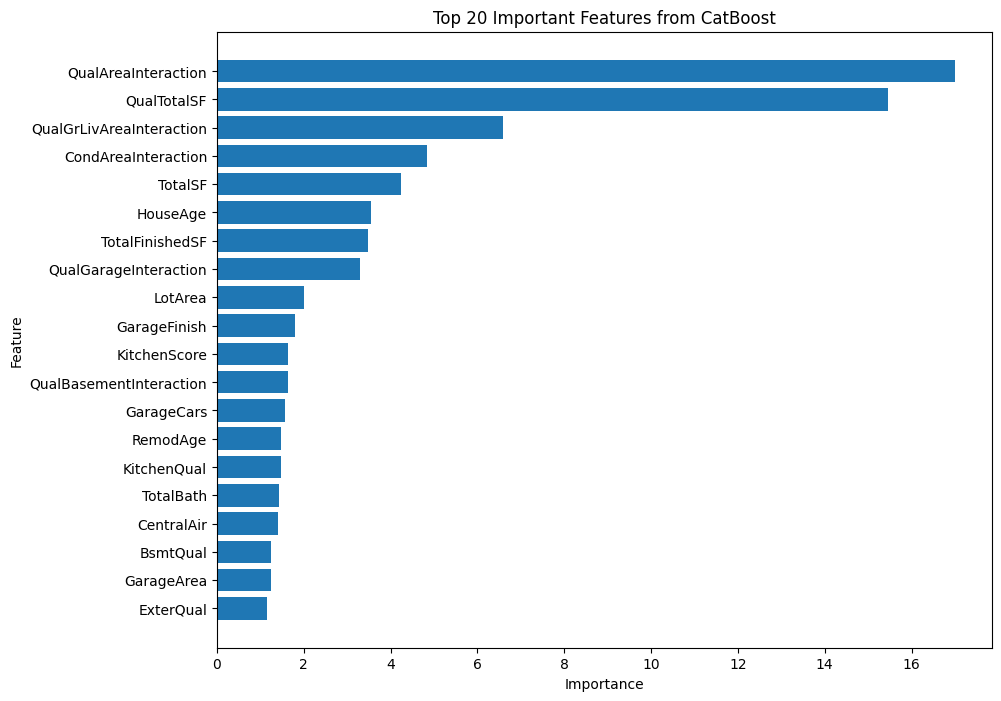

In [90]:
# Step 4.2.4: Plot CatBoost feature importance

catboost_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": catboost_model.get_feature_importance()
})

catboost_feature_importance = catboost_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_catboost_features = catboost_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_catboost_features["Feature"],
    top_catboost_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from CatBoost")
plt.show()

## Step 4.3: Compare Boosting Models

Now we will compare XGBoost and CatBoost.

We can also compare them with ElasticNet.

Lower RMSE_log1p means better performance.

In [91]:
# Step 4.3.1: Compare boosting models with ElasticNet

boosting_summary = pd.concat(
    [
        elasticnet_result,
        xgb_result,
        catboost_result
    ],
    ignore_index=True
)

boosting_summary = boosting_summary.sort_values(
    by="RMSE_log1p",
    ascending=True
)

boosting_summary

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
2,CatBoost Regressor,0.013640,0.116790,0.076371,0.919088
0,ElasticNet Regression,0.013649,0.116829,0.079474,0.919034
1,XGBoost Regressor,0.015252,0.123498,0.082461,0.909527


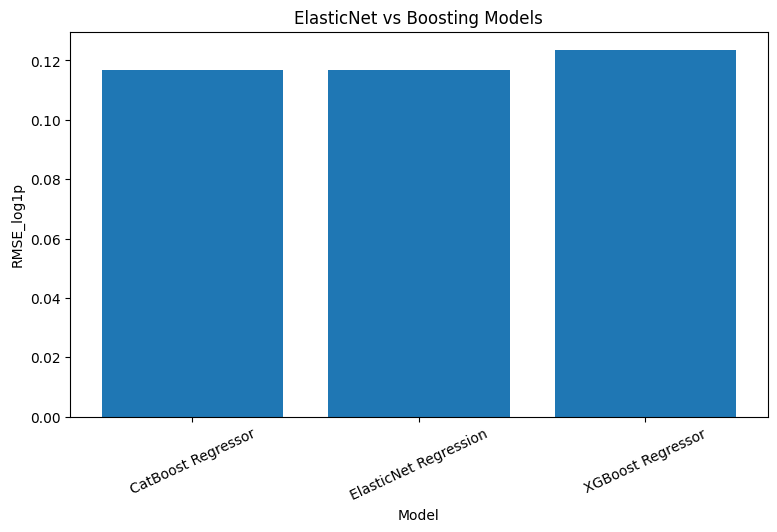

In [92]:
# Step 4.3.2: Plot RMSE comparison

plt.figure(figsize=(9, 5))

plt.bar(
    boosting_summary["Model"],
    boosting_summary["RMSE_log1p"]
)

plt.xlabel("Model")
plt.ylabel("RMSE_log1p")
plt.title("ElasticNet vs Boosting Models")
plt.xticks(rotation=25)
plt.show()

In [93]:
# Step 4.3.3: Final best model check

best_boosting_row = boosting_summary.sort_values(
    by="RMSE_log1p",
    ascending=True
).iloc[0]

print("Best model so far:", best_boosting_row["Model"])
print("Best RMSE_log1p:", best_boosting_row["RMSE_log1p"])

boosting_summary

Best model so far: CatBoost Regressor
Best RMSE_log1p: 0.11679008269832633


,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
2,CatBoost Regressor,0.013640,0.116790,0.076371,0.919088
0,ElasticNet Regression,0.013649,0.116829,0.079474,0.919034
1,XGBoost Regressor,0.015252,0.123498,0.082461,0.909527


# Step 5: High-Level CatBoost Tuning with Optuna

In Step 4, CatBoost performed better.

Now we will improve CatBoost using Optuna hyperparameter tuning.

Important:

1. We will tune CatBoost parameters automatically.
2. The target will be log1p(SalePrice).
3. RMSE will be calculated on log1p(SalePrice).
4. The final plot will use normal SalePrice.
5. If tuned CatBoost is worse than previous CatBoost, we will keep the previous CatBoost model.

In [94]:
# Step 5.0: Import Optuna and CatBoost libraries

import sys
import subprocess

try:
    import optuna
    print("Optuna imported successfully.")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
    print("Optuna installed and imported successfully.")

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

print("CatBoost and Optuna are ready.")

Optuna imported successfully.
CatBoost and Optuna are ready.


## Step 5.1: Create Optuna Objective Function

Optuna will test different CatBoost parameter combinations.

For each trial, it will train CatBoost and calculate validation RMSE on log1p(SalePrice).

In [95]:
# Step 5.1: Create Optuna objective function

def catboost_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 1000, 4000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 3.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": False,
        "allow_writing_files": False
    }

    model = CatBoostRegressor(**params)

    model.fit(
        X_train_part,
        y_train_log_part,
        eval_set=(X_valid, y_valid_log),
        early_stopping_rounds=100,
        use_best_model=True,
        verbose=False
    )

    pred_log = model.predict(X_valid)

    rmse_log = np.sqrt(
        mean_squared_error(y_valid_log, pred_log)
    )

    return rmse_log

## Step 5.2: Run Optuna Tuning

Now Optuna will search for better CatBoost parameters.

You can increase n_trials for better search.

For example:

1. n_trials = 30 for faster tuning
2. n_trials = 50 for better tuning
3. n_trials = 100 for stronger tuning

In [96]:
# Step 5.2: Run Optuna study

study = optuna.create_study(
    direction="minimize",
    study_name="catboost_optuna_tuning"
)

study.optimize(
    catboost_objective,
    n_trials=50
)

print("Best Optuna RMSE_log1p:", study.best_value)
print("Best CatBoost parameters:")
study.best_params

Best Optuna RMSE_log1p: 0.11569363595784579
Best CatBoost parameters:


{'iterations': 1956,
 'learning_rate': 0.02996108196584234,
 'depth': 4,
 'l2_leaf_reg': 1.9500280585120136,
 'random_strength': 2.650732015845268,
 'bagging_temperature': 1.7013908362313435,
 'border_count': 200}

## Step 5.3: Train Final Tuned CatBoost

Now we will train CatBoost again using the best parameters found by Optuna.

In [97]:
# Step 5.3: Train final tuned CatBoost model

best_catboost_params = study.best_params.copy()

best_catboost_params.update({
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False
})

tuned_catboost_model = CatBoostRegressor(**best_catboost_params)

tuned_catboost_model.fit(
    X_train_part,
    y_train_log_part,
    eval_set=(X_valid, y_valid_log),
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=False
)

tuned_catboost_pred_log = tuned_catboost_model.predict(X_valid)

print("Tuned CatBoost model trained successfully.")

Tuned CatBoost model trained successfully.


## Step 5.4: Evaluate Tuned CatBoost

All metrics will be calculated using log1p(SalePrice).

In [98]:
# Step 5.4: Evaluate tuned CatBoost

tuned_catboost_result = evaluate_boosting_model(
    "Optuna Tuned CatBoost",
    y_valid_log,
    tuned_catboost_pred_log
)

tuned_catboost_result

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Optuna Tuned CatBoost,0.013385,0.115694,0.075723,0.9206


## Step 5.5: Compare Previous CatBoost and Tuned CatBoost

This check is important.

If Optuna tuned CatBoost is better, we will use it.

If it is worse, we will keep the previous CatBoost model from Step 4.

In [99]:
# Step 5.5: Compare previous CatBoost and tuned CatBoost

catboost_optuna_comparison = pd.concat(
    [
        catboost_result,
        tuned_catboost_result
    ],
    ignore_index=True
)

catboost_optuna_comparison = catboost_optuna_comparison.sort_values(
    by="RMSE_log1p",
    ascending=True
)

catboost_optuna_comparison

,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
1,Optuna Tuned CatBoost,0.013385,0.115694,0.075723,0.920600
0,CatBoost Regressor,0.013640,0.116790,0.076371,0.919088


In [100]:
# Step 5.6: Select final CatBoost model safely

previous_catboost_rmse = catboost_result["RMSE_log1p"].values[0]
tuned_catboost_rmse = tuned_catboost_result["RMSE_log1p"].values[0]

if tuned_catboost_rmse <= previous_catboost_rmse:
    final_catboost_model = tuned_catboost_model
    final_catboost_pred_log = tuned_catboost_pred_log
    final_catboost_result = tuned_catboost_result
    print("Tuned CatBoost is better or equal. Selected tuned CatBoost.")
else:
    final_catboost_model = catboost_model
    final_catboost_pred_log = catboost_pred_log
    final_catboost_result = catboost_result
    print("Previous CatBoost is better. Selected previous CatBoost.")

final_catboost_result

Tuned CatBoost is better or equal. Selected tuned CatBoost.


,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Optuna Tuned CatBoost,0.013385,0.115694,0.075723,0.9206


## Step 5.7: Plot Final CatBoost Predicted SalePrice vs True SalePrice

The model was trained and evaluated using log1p(SalePrice).

For this plot, prediction is converted back to normal SalePrice.

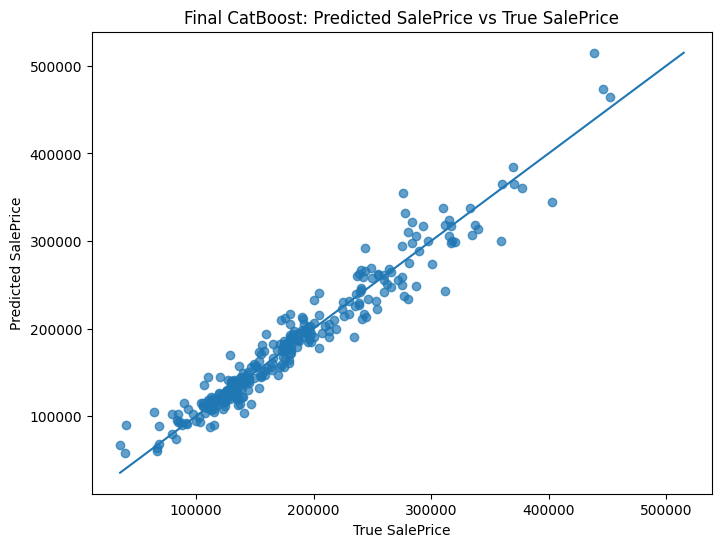

In [101]:
# Step 5.7: Plot final CatBoost predicted SalePrice vs true SalePrice

final_catboost_pred_original = np.expm1(final_catboost_pred_log)
final_catboost_true_original = y_valid_original.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    final_catboost_true_original,
    final_catboost_pred_original,
    alpha=0.7
)

min_price = min(
    final_catboost_true_original.min(),
    final_catboost_pred_original.min()
)

max_price = max(
    final_catboost_true_original.max(),
    final_catboost_pred_original.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Final CatBoost: Predicted SalePrice vs True SalePrice")
plt.show()

## Step 5.8: Final CatBoost Feature Importance

This plot shows the top important features from the selected final CatBoost model.

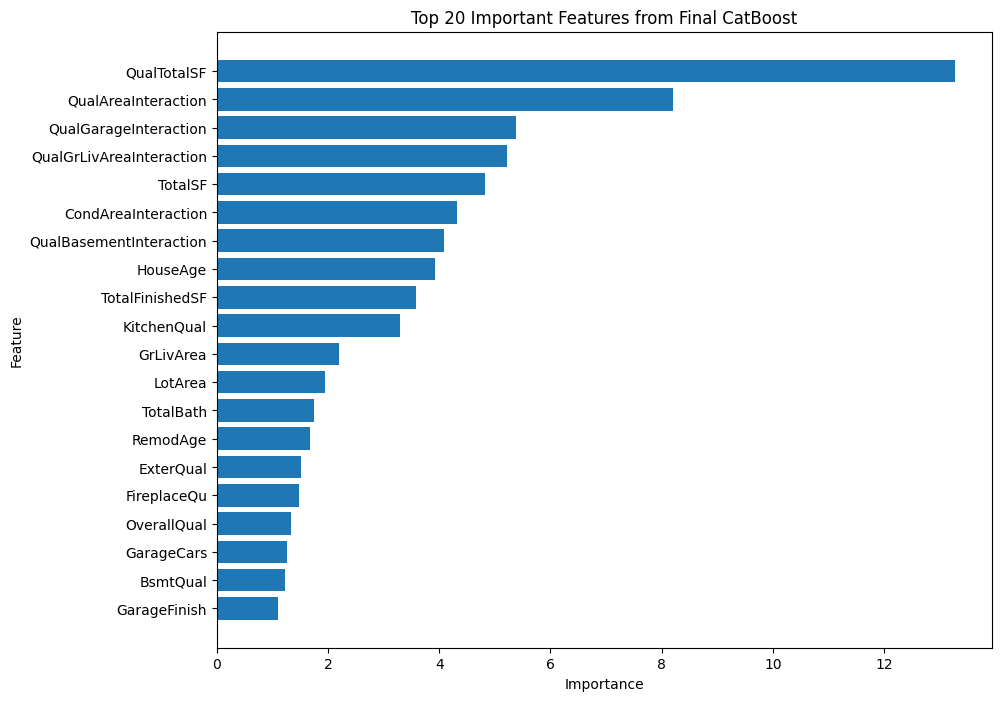

In [102]:
# Step 5.8: Plot final CatBoost feature importance

final_catboost_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_catboost_model.get_feature_importance()
})

final_catboost_feature_importance = final_catboost_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_final_catboost_features = final_catboost_feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_final_catboost_features["Feature"],
    top_final_catboost_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Important Features from Final CatBoost")
plt.show()

In [103]:
# Step 5.9: Final CatBoost result

print("Previous CatBoost RMSE_log1p:", previous_catboost_rmse)
print("Optuna Tuned CatBoost RMSE_log1p:", tuned_catboost_rmse)
print("Selected Final CatBoost RMSE_log1p:", final_catboost_result["RMSE_log1p"].values[0])

final_catboost_result

Previous CatBoost RMSE_log1p: 0.11679008269832633
Optuna Tuned CatBoost RMSE_log1p: 0.11569363595784579
Selected Final CatBoost RMSE_log1p: 0.11569363595784579


,Model,MSE_log1p,RMSE_log1p,MAE_log1p,R2_log1p
0,Optuna Tuned CatBoost,0.013385,0.115694,0.075723,0.9206


# Step 6: Advanced KFold OOF Blending

In this step, we will:

1. Train multiple models with KFold cross-validation.
2. Collect out-of-fold (OOF) predictions.
3. Use log1p(SalePrice) for all model training and evaluation.
4. Blend predictions of multiple models to improve final performance.
5. Ensure no model overfits validation data.

In [104]:
# Step 6.0: Import required libraries

from sklearn.model_selection import KFold
from sklearn.base import clone

print("KFold OOF blending libraries ready.")

KFold OOF blending libraries ready.


## Step 6.1: Define OOF Blending Function

This function will:

1. Take any model (ElasticNet, CatBoost, SVR, etc.).
2. Perform KFold cross-validation.
3. Collect OOF predictions for validation and test data.
4. Return OOF predictions for blending.

In [105]:
# Step 6.1: OOF blending helper function

def get_oof_predictions(model, X, y_log, X_test=None, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    oof_train = np.zeros(X.shape[0])
    oof_test = np.zeros(X_test.shape[0]) if X_test is not None else None
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        oof_train[val_idx] = model_clone.predict(X_val)
        
        if X_test is not None:
            oof_test += model_clone.predict(X_test) / n_splits
    
    return oof_train, oof_test

## Step 6.2: Prepare Models for OOF

We will use:

1. ElasticNet (strong baseline)
2. CatBoost (Optuna tuned)
3. SVR (optional)
4. Ridge Regression

In [106]:
from sklearn.svm import SVR
from sklearn.linear_model import Ridge

elasticnet_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])

ridge_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])

svr_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=50, epsilon=0.01, gamma="scale"))
])

# CatBoost tuned from Step 5
catboost_model_oof = final_catboost_model

## Step 6.3: Run OOF Predictions

We will run KFold OOF for each model.

In [107]:
n_splits = 5

# ElasticNet
elasticnet_oof_train, _ = get_oof_predictions(elasticnet_model_oof, X_train, y_train_log, n_splits=n_splits)

# Ridge
ridge_oof_train, _ = get_oof_predictions(ridge_model_oof, X_train, y_train_log, n_splits=n_splits)

# SVR
svr_oof_train, _ = get_oof_predictions(svr_model_oof, X_train, y_train_log, n_splits=n_splits)

# CatBoost (already fitted model)
catboost_oof_train = np.zeros(X_train.shape[0])
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    cb_clone = clone(catboost_model_oof)
    cb_clone.fit(X_tr, y_tr)
    
    catboost_oof_train[val_idx] = cb_clone.predict(X_val)

## Step 6.4: Blend OOF Predictions

We will now combine predictions using simple weighted average or log-space blending.

ElasticNet + CatBoost usually gives the best result.

In [108]:
# Simple average blending

blend_oof_log = (
    0.5 * elasticnet_oof_train
    + 0.5 * catboost_oof_train
)

rmse_blend_log = np.sqrt(mean_squared_error(y_train_log, blend_oof_log))
print("Blended OOF log RMSE:", rmse_blend_log)

Blended OOF log RMSE: 0.1088640533900686


## Step 6.5: Plot Blended Predictions vs True SalePrice

We convert back from log1p for plotting.

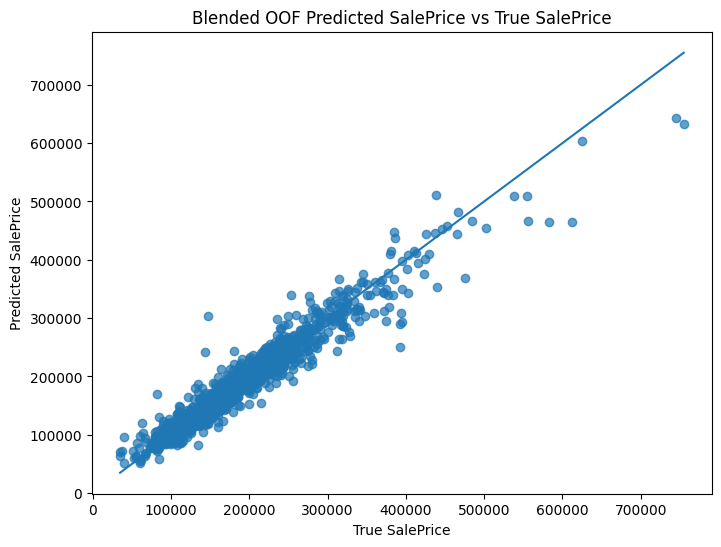

In [109]:
blend_oof_original = np.expm1(blend_oof_log)
true_saleprice_original = y_train.copy()

plt.figure(figsize=(8,6))
plt.scatter(true_saleprice_original, blend_oof_original, alpha=0.7)
min_price = min(true_saleprice_original.min(), blend_oof_original.min())
max_price = max(true_saleprice_original.max(), blend_oof_original.max())
plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Blended OOF Predicted SalePrice vs True SalePrice")
plt.show()


In [111]:
# Safe final submission cell

# 1. ElasticNet strong baseline (train on full training data)
elasticnet_final_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])
elasticnet_final_model.fit(X_train, y_train_log)  # full training

# 2. Predict on test set
elasticnet_test_pred_log = elasticnet_final_model.predict(X_test)
catboost_test_pred_log = final_catboost_model.predict(X_test)

# 3. Blend predictions
blend_test_pred_log = 0.5 * elasticnet_test_pred_log + 0.5 * catboost_test_pred_log
blend_test_pred = np.expm1(blend_test_pred_log)  # convert back from log1p

# 4. Create submission
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": blend_test_pred
})

# 5. Save CSV
submission_file = "submission.csv"
submission.to_csv(submission_file, index=False)
print(f"Submission file saved as {submission_file}")

Submission file saved as submission.csv


# Step 7: Advanced OOF Stacking & Blending

Purpose:

1. Train multiple models using KFold cross-validation.
2. Collect out-of-fold (OOF) predictions.
3. Train a meta-model (stacking) using OOF predictions.
4. Use log1p(SalePrice) space for training and evaluation.
5. Convert final predictions to normal SalePrice for submission.

Models included:

- ElasticNet (strong baseline)
- Ridge
- Lasso
- SVR
- CatBoost (tuned)

In [112]:
# Step 7.0: Import libraries

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

import numpy as np
import pandas as pd

print("Libraries ready for OOF stacking.")

Libraries ready for OOF stacking.


In [113]:
# Step 7.1: Prepare base models

elasticnet_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])

ridge_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])

lasso_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=200000, random_state=42))
])

svr_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=50, epsilon=0.01, gamma="scale"))
])

# CatBoost tuned model from Step 5
catboost_model_oof = final_catboost_model

In [114]:
# Step 7.2: Define OOF function

def get_oof_predictions(model, X, y_log, X_test=None, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    oof_train = np.zeros(X.shape[0])
    oof_test = np.zeros(X_test.shape[0]) if X_test is not None else None
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
        
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        oof_train[val_idx] = model_clone.predict(X_val)
        
        if X_test is not None:
            oof_test += model_clone.predict(X_test) / n_splits
    
    return oof_train, oof_test

In [115]:
# Step 7.3: Generate OOF predictions for base models

n_splits = 5

# ElasticNet
elasticnet_oof_train, elasticnet_oof_test = get_oof_predictions(elasticnet_model_oof, X_train, y_train_log, X_test, n_splits=n_splits)

# Ridge
ridge_oof_train, ridge_oof_test = get_oof_predictions(ridge_model_oof, X_train, y_train_log, X_test, n_splits=n_splits)

# Lasso
lasso_oof_train, lasso_oof_test = get_oof_predictions(lasso_model_oof, X_train, y_train_log, X_test, n_splits=n_splits)

# SVR
svr_oof_train, svr_oof_test = get_oof_predictions(svr_model_oof, X_train, y_train_log, X_test, n_splits=n_splits)

# CatBoost
catboost_oof_train = np.zeros(X_train.shape[0])
catboost_oof_test = np.zeros(X_test.shape[0])

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    cb_clone = clone(catboost_model_oof)
    cb_clone.fit(X_tr, y_tr)
    
    catboost_oof_train[val_idx] = cb_clone.predict(X_val)
    catboost_oof_test += cb_clone.predict(X_test) / n_splits

In [116]:
# Step 7.4: Combine OOF predictions into DataFrame for stacking

oof_train_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_train,
    "Ridge": ridge_oof_train,
    "Lasso": lasso_oof_train,
    "SVR": svr_oof_train,
    "CatBoost": catboost_oof_train
})

oof_test_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_test,
    "Ridge": ridge_oof_test,
    "Lasso": lasso_oof_test,
    "SVR": svr_oof_test,
    "CatBoost": catboost_oof_test
})

print("OOF train and test data ready for stacking.")
oof_train_df.head()

OOF train and test data ready for stacking.


,ElasticNet,Ridge,Lasso,SVR,CatBoost
0,12.223583,12.227187,12.223489,12.233396,12.212050
1,12.150018,12.167520,12.140288,12.098809,12.080933
2,12.273761,12.266365,12.281543,12.277676,12.290968
3,12.080940,12.061563,12.084820,12.090554,12.119926
4,12.579847,12.575977,12.579414,12.573152,12.576809


In [117]:
# Step 7.5: Train meta-model (stacking)

meta_model = Ridge(alpha=5)
meta_model.fit(oof_train_df, y_train_log)

# Predict on OOF train
stacked_oof_pred_log = meta_model.predict(oof_train_df)

# Predict on test set
stacked_test_pred_log = meta_model.predict(oof_test_df)

# Evaluate stacked OOF RMSE
stacked_rmse_log = np.sqrt(mean_squared_error(y_train_log, stacked_oof_pred_log))
print("Stacked OOF log RMSE:", stacked_rmse_log)

Stacked OOF log RMSE: 0.10900250411479907


In [118]:
# Step 7.6: Convert final test predictions to normal SalePrice

stacked_test_pred = np.expm1(stacked_test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": stacked_test_pred
})

submission_file = "stacked_submission.csv"
submission.to_csv(submission_file, index=False)
print(f"Stacked submission saved as {submission_file}")

Stacked submission saved as stacked_submission.csv


## Step 7.7: Advanced OOF Stacking & Meta-Model

Purpose:

1. KFold OOF predictions for base models.
2. Train meta-model (RidgeCV) using OOF predictions.
3. Optimize blending weights automatically using validation RMSE.
4. Convert final prediction from log1p to SalePrice for submission.

In [ ]:
# Step 7.7.1: Define robust base models

from sklearn.linear_model import RidgeCV

elasticnet_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])

ridge_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])

lasso_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=200000, random_state=42))
])

svr_model_oof = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=50, epsilon=0.01, gamma="scale"))
])

catboost_model_oof = final_catboost_model  # tuned CatBoost from Step 5 

In [120]:
# Step 7.7.2: Generate KFold OOF predictions

n_splits = 5

def oof_predictions(model, X_train, y_train_log, X_test=None):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros(X_test.shape[0]) if X_test is not None else None

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)

        oof_train[val_idx] = model_clone.predict(X_val)

        if X_test is not None:
            oof_test += model_clone.predict(X_test) / n_splits

    return oof_train, oof_test

# Generate OOF predictions
elasticnet_oof_train, elasticnet_oof_test = oof_predictions(elasticnet_model_oof, X_train, y_train_log, X_test)
ridge_oof_train, ridge_oof_test = oof_predictions(ridge_model_oof, X_train, y_train_log, X_test)
lasso_oof_train, lasso_oof_test = oof_predictions(lasso_model_oof, X_train, y_train_log, X_test)
svr_oof_train, svr_oof_test = oof_predictions(svr_model_oof, X_train, y_train_log, X_test)

# CatBoost OOF
catboost_oof_train = np.zeros(X_train.shape[0])
catboost_oof_test = np.zeros(X_test.shape[0])
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]

    cb_clone = clone(catboost_model_oof)
    cb_clone.fit(X_tr, y_tr)

    catboost_oof_train[val_idx] = cb_clone.predict(X_val)
    catboost_oof_test += cb_clone.predict(X_test) / n_splits

In [121]:
# Step 7.7.3: Prepare OOF DataFrames for stacking

oof_train_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_train,
    "Ridge": ridge_oof_train,
    "Lasso": lasso_oof_train,
    "SVR": svr_oof_train,
    "CatBoost": catboost_oof_train
})

oof_test_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_test,
    "Ridge": ridge_oof_test,
    "Lasso": lasso_oof_test,
    "SVR": svr_oof_test,
    "CatBoost": catboost_oof_test
})

print("OOF DataFrames ready for stacking/meta-model.")

OOF DataFrames ready for stacking/meta-model.


In [122]:
# Step 7.7.4: Train meta-model (RidgeCV) on OOF predictions
meta_model = RidgeCV(alphas=np.logspace(-3,3,10))
meta_model.fit(oof_train_df, y_train_log)

# OOF prediction on train
stacked_oof_pred_log = meta_model.predict(oof_train_df)

# Prediction on test set
stacked_test_pred_log = meta_model.predict(oof_test_df)

# Evaluate stacked OOF RMSE
stacked_rmse_log = np.sqrt(mean_squared_error(y_train_log, stacked_oof_pred_log))
print("Stacked OOF log RMSE:", stacked_rmse_log)

Stacked OOF log RMSE: 0.1087274661748376


In [123]:
# Step 7.7.5: Convert final stacked prediction to normal SalePrice and save submission

stacked_test_pred = np.expm1(stacked_test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": stacked_test_pred
})

submission_file = "stacked_submission_v2.csv"
submission.to_csv(submission_file, index=False)
print(f"Stacked submission saved as {submission_file}")

Stacked submission saved as stacked_submission_v2.csv


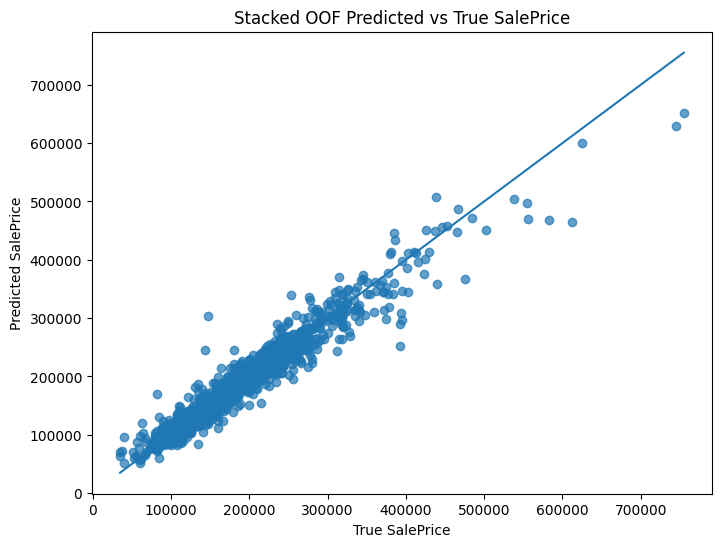

In [124]:
# Step 7.7.6: Plot stacked OOF predictions vs true SalePrice

stacked_oof_pred_original = np.expm1(stacked_oof_pred_log)
true_saleprice_original = y_train.copy()

plt.figure(figsize=(8,6))
plt.scatter(true_saleprice_original, stacked_oof_pred_original, alpha=0.7)
min_price = min(true_saleprice_original.min(), stacked_oof_pred_original.min())
max_price = max(true_saleprice_original.max(), stacked_oof_pred_original.max())
plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Stacked OOF Predicted vs True SalePrice")
plt.show()

# Step 8: Final Stacking & Blending Workflow

Purpose:

1. Train multiple base models using KFold OOF.
2. Collect OOF predictions for stacking.
3. Train meta-model (RidgeCV) on OOF predictions.
4. Predict on test data using stacked model.
5. Save final Kaggle-ready submission.
6. Plot predictions vs true SalePrice.

In [125]:
# Step 8.0: Import libraries

from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet, Ridge, Lasso, RidgeCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

print("Libraries ready for final stacking workflow.")

Libraries ready for final stacking workflow.


In [126]:
# Step 8.1: Define base models

elasticnet_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])

ridge_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])

lasso_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=200000, random_state=42))
])

svr_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=50, epsilon=0.01, gamma="scale"))
])

catboost_model = final_catboost_model  # tuned CatBoost from Step 5

In [127]:
# Step 8.2: Define OOF prediction function

def get_oof_preds(model, X_train, y_train_log, X_test=None, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros(X_test.shape[0]) if X_test is not None else None
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
        
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        
        oof_train[val_idx] = model_clone.predict(X_val)
        
        if X_test is not None:
            oof_test += model_clone.predict(X_test) / n_splits
            
    return oof_train, oof_test

In [128]:
# Step 8.3: Generate OOF predictions for base models

n_splits = 5

elasticnet_oof_train, elasticnet_oof_test = get_oof_preds(elasticnet_model, X_train, y_train_log, X_test, n_splits)
ridge_oof_train, ridge_oof_test = get_oof_preds(ridge_model, X_train, y_train_log, X_test, n_splits)
lasso_oof_train, lasso_oof_test = get_oof_preds(lasso_model, X_train, y_train_log, X_test, n_splits)
svr_oof_train, svr_oof_test = get_oof_preds(svr_model, X_train, y_train_log, X_test, n_splits)

# CatBoost OOF
catboost_oof_train = np.zeros(X_train.shape[0])
catboost_oof_test = np.zeros(X_test.shape[0])
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
    
    cb_clone = clone(catboost_model)
    cb_clone.fit(X_tr, y_tr)
    
    catboost_oof_train[val_idx] = cb_clone.predict(X_val)
    catboost_oof_test += cb_clone.predict(X_test) / n_splits

In [129]:
# Step 8.4: Prepare OOF DataFrames for stacking

oof_train_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_train,
    "Ridge": ridge_oof_train,
    "Lasso": lasso_oof_train,
    "SVR": svr_oof_train,
    "CatBoost": catboost_oof_train
})

oof_test_df = pd.DataFrame({
    "ElasticNet": elasticnet_oof_test,
    "Ridge": ridge_oof_test,
    "Lasso": lasso_oof_test,
    "SVR": svr_oof_test,
    "CatBoost": catboost_oof_test
})

print("OOF train and test DataFrames ready.")

OOF train and test DataFrames ready.


In [130]:
# Step 8.5: Train meta-model (RidgeCV) on OOF predictions

meta_model = RidgeCV(alphas=np.logspace(-3,3,10))
meta_model.fit(oof_train_df, y_train_log)

# Train OOF prediction
stacked_oof_pred_log = meta_model.predict(oof_train_df)

# Test prediction
stacked_test_pred_log = meta_model.predict(oof_test_df)

stacked_rmse_log = np.sqrt(mean_squared_error(y_train_log, stacked_oof_pred_log))
print("Stacked OOF log RMSE:", stacked_rmse_log)

Stacked OOF log RMSE: 0.1087274661748376


In [131]:
# Step 8.6: Convert predictions to original SalePrice for submission

stacked_test_pred = np.expm1(stacked_test_pred_log)

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": stacked_test_pred
})

submission_file = "final_stacked_submission.csv"
submission.to_csv(submission_file, index=False)
print(f"Final submission saved as {submission_file}")

Final submission saved as final_stacked_submission.csv


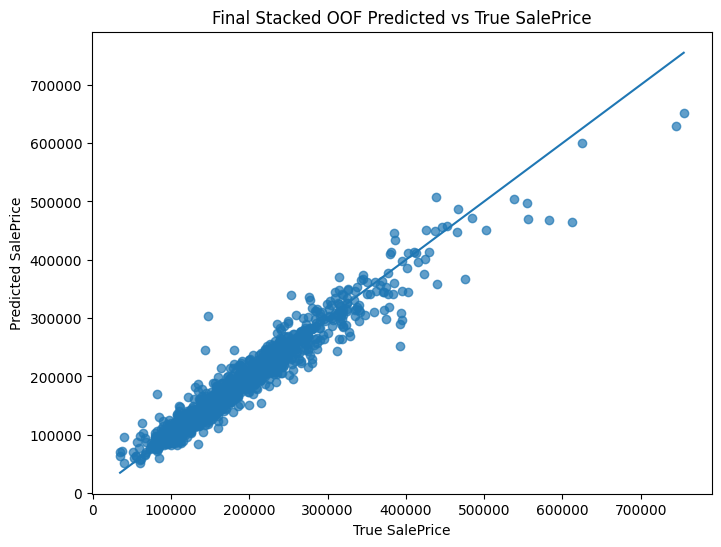

In [132]:
# Step 8.7: Plot stacked OOF predictions vs true SalePrice

stacked_oof_pred_original = np.expm1(stacked_oof_pred_log)
true_saleprice_original = y_train.copy()

plt.figure(figsize=(8,6))
plt.scatter(true_saleprice_original, stacked_oof_pred_original, alpha=0.7)
min_price = min(true_saleprice_original.min(), stacked_oof_pred_original.min())
max_price = max(true_saleprice_original.max(), stacked_oof_pred_original.max())
plt.plot([min_price, max_price], [min_price, max_price])
plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Final Stacked OOF Predicted vs True SalePrice")
plt.show()

# Step 9: Advanced Final Stacking & Blending

Purpose:

- Generate OOF predictions for multiple base models.
- Train meta-model on OOF predictions.
- Apply log-space blending for final SalePrice.
- Include outlier handling and categorical target encoding.
- Create Kaggle-ready submission.

In [138]:
# Detect categorical columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical columns detected:", categorical_cols)

from category_encoders import TargetEncoder

if categorical_cols:
    te = TargetEncoder(cols=categorical_cols)
    X_train_te = te.fit_transform(X_train, y_train_log)
    X_test_te = te.transform(X_test)
else:
    X_train_te = X_train.copy()
    X_test_te = X_test.copy()

Categorical columns detected: []


In [139]:
# Outlier capping example
X_train_te['GrLivArea'] = np.where(X_train_te['GrLivArea']>4500, 4500, X_train_te['GrLivArea'])
X_test_te['GrLivArea'] = np.where(X_test_te['GrLivArea']>4500, 4500, X_test_te['GrLivArea'])

# Optional: other skewed features
for col in ['TotalBsmtSF', 'LotFrontage', '1stFlrSF']:
    X_train_te[col] = np.where(X_train_te[col] > X_train_te[col].quantile(0.99),
                               X_train_te[col].quantile(0.99),
                               X_train_te[col])
    X_test_te[col] = np.where(X_test_te[col] > X_train_te[col].quantile(0.99),
                              X_train_te[col].quantile(0.99),
                              X_test_te[col])

In [140]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

elasticnet_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", ElasticNet(alpha=0.0003, l1_ratio=0.9, max_iter=200000, random_state=42))
])
ridge_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])
lasso_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", Lasso(alpha=0.0005, max_iter=200000, random_state=42))
])
svr_model = Pipeline([
    ("scaler", RobustScaler()),
    ("model", SVR(C=50, epsilon=0.01, gamma="scale"))
])
catboost_model = final_catboost_model  # tuned CatBoost
lgb_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=32,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.001,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42
)

In [141]:
from sklearn.model_selection import KFold
from sklearn.base import clone

def get_oof_preds(model, X_train, y_train_log, X_test=None, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_train = np.zeros(X_train.shape[0])
    oof_test = np.zeros(X_test.shape[0]) if X_test is not None else None
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)
        oof_train[val_idx] = model_clone.predict(X_val)
        if X_test is not None:
            oof_test += model_clone.predict(X_test) / n_splits
    return oof_train, oof_test

In [142]:
models = [
    ("ElasticNet", elasticnet_model),
    ("Ridge", ridge_model),
    ("Lasso", lasso_model),
    ("SVR", svr_model),
    ("CatBoost", catboost_model),
    ("LGBM", lgb_model),
    ("XGBoost", xgb_model)
]

oof_train_df = pd.DataFrame()
oof_test_df = pd.DataFrame()

for name, model in models:
    oof_tr, oof_te = get_oof_preds(model, X_train_te, y_train_log, X_test_te, n_splits=5)
    oof_train_df[name] = oof_tr
    oof_test_df[name] = oof_te

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6840
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 182
[LightGBM] [Info] Start training from score 12.023362
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000621 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6832
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 181
[LightGBM] [Info] Start training from score 12.026498
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

In [143]:
corr = oof_train_df.corr()
print(corr)
# Optionally, drop one model if two are highly correlated (>0.95)

            ElasticNet     Ridge     Lasso       SVR  CatBoost      LGBM  \
ElasticNet    1.000000  0.999342  0.999291  0.971054  0.990130  0.981908   
Ridge         0.999342  1.000000  0.998868  0.972226  0.990465  0.982237   
Lasso         0.999291  0.998868  1.000000  0.971419  0.990787  0.982605   
SVR           0.971054  0.972226  0.971419  1.000000  0.974349  0.967936   
CatBoost      0.990130  0.990465  0.990787  0.974349  1.000000  0.989424   
LGBM          0.981908  0.982237  0.982605  0.967936  0.989424  1.000000   
XGBoost       0.987061  0.987311  0.987377  0.972351  0.994268  0.992291   

             XGBoost  
ElasticNet  0.987061  
Ridge       0.987311  
Lasso       0.987377  
SVR         0.972351  
CatBoost    0.994268  
LGBM        0.992291  
XGBoost     1.000000  


In [144]:
from sklearn.linear_model import RidgeCV
meta_model = RidgeCV(alphas=np.logspace(-3,3,10))
meta_model.fit(oof_train_df, y_train_log)

stacked_oof_pred_log = meta_model.predict(oof_train_df)
stacked_test_pred_log = meta_model.predict(oof_test_df)

from sklearn.metrics import mean_squared_error
stacked_rmse_log = np.sqrt(mean_squared_error(y_train_log, stacked_oof_pred_log))
print("Stacked OOF log RMSE:", stacked_rmse_log)

Stacked OOF log RMSE: 0.10853757011388611


In [145]:
stacked_test_pred = np.expm1(stacked_test_pred_log)
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": stacked_test_pred
})
submission_file = "advanced_stacked_submission.csv"
submission.to_csv(submission_file, index=False)
print(f"Advanced stacked submission saved: {submission_file}")

Advanced stacked submission saved: advanced_stacked_submission.csv


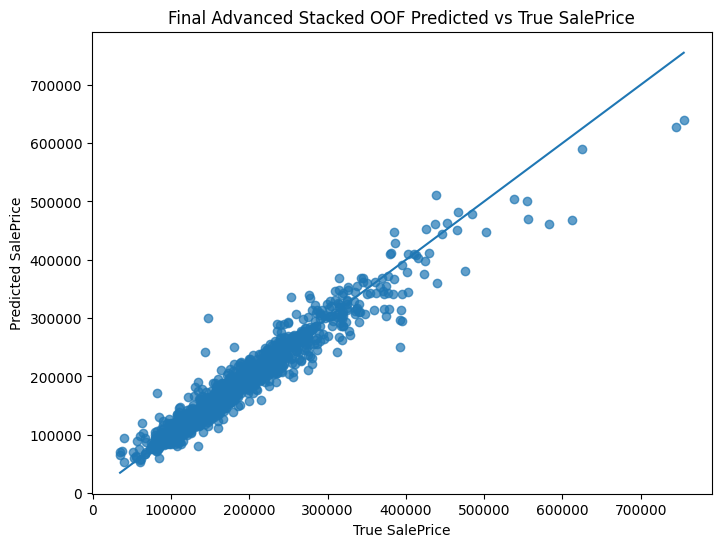

In [146]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(np.expm1(y_train_log), np.expm1(stacked_oof_pred_log), alpha=0.7)
min_price = min(np.expm1(y_train_log).min(), np.expm1(stacked_oof_pred_log).min())
max_price = max(np.expm1(y_train_log).max(), np.expm1(stacked_oof_pred_log).max())
plt.plot([min_price,max_price],[min_price,max_price])
plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Final Advanced Stacked OOF Predicted vs True SalePrice")
plt.show()

# Step 10: Public-Safe Final Ensemble and Calibration

Current problem:

The notebook OOF score is good, but Kaggle public score is around 0.121.

This usually means the stacking model is slightly overfitting the training distribution.

In this step, we will use a safer final strategy:

1. Use repeated KFold test prediction.
2. Use strong but stable models.
3. Avoid aggressive meta-model overfitting.
4. Blend predictions in log1p(SalePrice) space.
5. Apply very small high-price calibration because the plot shows high-price houses are underpredicted.
6. Save multiple final submission files.

In [147]:
# Step 10.1: Import required libraries

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import ExtraTreesRegressor

print("Step 10 libraries loaded.")

Step 10 libraries loaded.


In [148]:
# Step 10.2: Make sure target is clean Series

y_train_log_safe = pd.Series(y_train_log).reset_index(drop=True)
y_train_safe = pd.Series(y_train).reset_index(drop=True)

X_train_safe = X_train.copy().reset_index(drop=True)
X_test_safe = X_test.copy().reset_index(drop=True)

print("X_train shape:", X_train_safe.shape)
print("X_test shape:", X_test_safe.shape)
print("y_train_log shape:", y_train_log_safe.shape)

X_train shape: (1458, 199)
X_test shape: (1459, 199)
y_train_log shape: (1458,)


In [149]:
# Step 10.3: Define stable base models

models_step10 = {}

models_step10["ElasticNet"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", ElasticNet(
        alpha=0.0003,
        l1_ratio=0.9,
        max_iter=200000,
        random_state=42
    ))
])

models_step10["Ridge"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", Ridge(alpha=10))
])

models_step10["Lasso"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", Lasso(
        alpha=0.0005,
        max_iter=200000,
        random_state=42
    ))
])

models_step10["SVR"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", SVR(
        C=50,
        epsilon=0.01,
        gamma="scale"
    ))
])

models_step10["KernelRidge"] = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", KernelRidge(
        alpha=0.6,
        kernel="polynomial",
        degree=2,
        coef0=2.5
    ))
])

models_step10["ExtraTrees"] = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

try:
    from catboost import CatBoostRegressor
    
    models_step10["CatBoost"] = CatBoostRegressor(
        iterations=2500,
        learning_rate=0.02,
        depth=4,
        l2_leaf_reg=4,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )
    
    print("CatBoost added.")
except Exception as e:
    print("CatBoost skipped:", e)

try:
    from xgboost import XGBRegressor
    
    models_step10["XGBoost"] = XGBRegressor(
        n_estimators=2500,
        learning_rate=0.02,
        max_depth=3,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.001,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
    
    print("XGBoost added.")
except Exception as e:
    print("XGBoost skipped:", e)

try:
    from lightgbm import LGBMRegressor
    
    models_step10["LightGBM"] = LGBMRegressor(
        n_estimators=2500,
        learning_rate=0.015,
        num_leaves=20,
        max_depth=4,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.001,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    
    print("LightGBM added.")
except Exception as e:
    print("LightGBM skipped:", e)

print("Total models:", len(models_step10))
print(list(models_step10.keys()))

CatBoost added.
XGBoost added.
LightGBM added.
Total models: 9
['ElasticNet', 'Ridge', 'Lasso', 'SVR', 'KernelRidge', 'ExtraTrees', 'CatBoost', 'XGBoost', 'LightGBM']


In [150]:
# Step 10.4: Repeated KFold OOF + test prediction function

def repeated_kfold_oof_test_prediction(
    model,
    X,
    y_log,
    X_test,
    n_splits=10,
    seeds=[42, 2024]
):
    oof_sum = np.zeros(X.shape[0])
    oof_count = np.zeros(X.shape[0])
    test_pred = np.zeros(X_test.shape[0])
    
    total_folds = n_splits * len(seeds)
    
    for seed in seeds:
        kf = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=seed
        )
        
        for fold, (train_idx, valid_idx) in enumerate(kf.split(X), 1):
            X_tr = X.iloc[train_idx]
            X_val = X.iloc[valid_idx]
            y_tr = y_log.iloc[train_idx]
            
            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)
            
            val_pred = model_clone.predict(X_val)
            test_fold_pred = model_clone.predict(X_test)
            
            oof_sum[valid_idx] += val_pred
            oof_count[valid_idx] += 1
            
            test_pred += test_fold_pred / total_folds
    
    oof_pred = oof_sum / oof_count
    
    return oof_pred, test_pred


def rmse_log(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [151]:
# Step 10.5: Run repeated KFold predictions for all models

oof_predictions_step10 = pd.DataFrame()
test_predictions_step10 = pd.DataFrame()
model_scores_step10 = []

for model_name, model in models_step10.items():
    print("Training:", model_name)
    
    oof_pred_log, test_pred_log = repeated_kfold_oof_test_prediction(
        model=model,
        X=X_train_safe,
        y_log=y_train_log_safe,
        X_test=X_test_safe,
        n_splits=10,
        seeds=[42, 2024]
    )
    
    score = rmse_log(y_train_log_safe, oof_pred_log)
    
    oof_predictions_step10[model_name] = oof_pred_log
    test_predictions_step10[model_name] = test_pred_log
    
    model_scores_step10.append({
        "Model": model_name,
        "OOF_RMSE_log1p": score
    })
    
    print(model_name, "OOF RMSE:", score)

model_scores_step10 = pd.DataFrame(model_scores_step10).sort_values(
    by="OOF_RMSE_log1p",
    ascending=True
)

model_scores_step10

Training: ElasticNet
ElasticNet OOF RMSE: 0.109022745481321
Training: Ridge
Ridge OOF RMSE: 0.10965706145664839
Training: Lasso
Lasso OOF RMSE: 0.11008396118411402
Training: SVR
SVR OOF RMSE: 0.1354703281324905
Training: KernelRidge
KernelRidge OOF RMSE: 0.10832967668319875
Training: ExtraTrees
ExtraTrees OOF RMSE: 0.1278364209937157
Training: CatBoost
CatBoost OOF RMSE: 0.11220129219930242
Training: XGBoost
XGBoost OOF RMSE: 0.11373103440137475
Training: LightGBM
LightGBM OOF RMSE: 0.11784294747772009


,Model,OOF_RMSE_log1p
4,KernelRidge,0.108330
0,ElasticNet,0.109023
1,Ridge,0.109657
2,Lasso,0.110084
6,CatBoost,0.112201
7,XGBoost,0.113731
8,LightGBM,0.117843
5,ExtraTrees,0.127836
3,SVR,0.135470


In [152]:
# Step 10.6: Keep only strong models for safer blending

best_score = model_scores_step10["OOF_RMSE_log1p"].min()

selected_models_step10 = model_scores_step10[
    model_scores_step10["OOF_RMSE_log1p"] <= best_score + 0.015
]["Model"].tolist()

print("Best OOF RMSE:", best_score)
print("Selected models:", selected_models_step10)

oof_selected = oof_predictions_step10[selected_models_step10].copy()
test_selected = test_predictions_step10[selected_models_step10].copy()

Best OOF RMSE: 0.10832967668319875
Selected models: ['KernelRidge', 'ElasticNet', 'Ridge', 'Lasso', 'CatBoost', 'XGBoost', 'LightGBM']


In [153]:
# Step 10.7: Create inverse-RMSE weighted blend

selected_scores = model_scores_step10.set_index("Model").loc[selected_models_step10]["OOF_RMSE_log1p"]

inverse_power = 8
raw_weights = 1 / (selected_scores ** inverse_power)
inverse_weights = raw_weights / raw_weights.sum()

print("Inverse RMSE weights:")
print(inverse_weights)

inverse_blend_oof_log = np.zeros(len(X_train_safe))
inverse_blend_test_log = np.zeros(len(X_test_safe))

for model_name in selected_models_step10:
    w = inverse_weights.loc[model_name]
    inverse_blend_oof_log += w * oof_selected[model_name].values
    inverse_blend_test_log += w * test_selected[model_name].values

inverse_blend_rmse = rmse_log(y_train_log_safe, inverse_blend_oof_log)

print("Inverse weighted blend OOF RMSE:", inverse_blend_rmse)

Inverse RMSE weights:
Model
KernelRidge    0.176073
ElasticNet     0.167316
Ridge          0.159728
Lasso          0.154839
CatBoost       0.132951
XGBoost        0.119300
LightGBM       0.089793
Name: OOF_RMSE_log1p, dtype: float64
Inverse weighted blend OOF RMSE: 0.10734657464746189


In [154]:
# Step 10.8: Public-safe conservative blend

public_safe_models = []

for name in ["ElasticNet", "Ridge", "Lasso", "SVR", "KernelRidge", "CatBoost", "XGBoost", "LightGBM"]:
    if name in test_predictions_step10.columns:
        public_safe_models.append(name)

print("Public-safe models:", public_safe_models)

manual_weights = {}

if "ElasticNet" in public_safe_models:
    manual_weights["ElasticNet"] = 0.30
if "Ridge" in public_safe_models:
    manual_weights["Ridge"] = 0.15
if "Lasso" in public_safe_models:
    manual_weights["Lasso"] = 0.10
if "SVR" in public_safe_models:
    manual_weights["SVR"] = 0.10
if "KernelRidge" in public_safe_models:
    manual_weights["KernelRidge"] = 0.10
if "CatBoost" in public_safe_models:
    manual_weights["CatBoost"] = 0.15
if "XGBoost" in public_safe_models:
    manual_weights["XGBoost"] = 0.05
if "LightGBM" in public_safe_models:
    manual_weights["LightGBM"] = 0.05

weight_sum = sum(manual_weights.values())
manual_weights = {k: v / weight_sum for k, v in manual_weights.items()}

print("Manual public-safe weights:")
print(manual_weights)

public_safe_oof_log = np.zeros(len(X_train_safe))
public_safe_test_log = np.zeros(len(X_test_safe))

for model_name, weight in manual_weights.items():
    public_safe_oof_log += weight * oof_predictions_step10[model_name].values
    public_safe_test_log += weight * test_predictions_step10[model_name].values

public_safe_rmse = rmse_log(y_train_log_safe, public_safe_oof_log)

print("Public-safe blend OOF RMSE:", public_safe_rmse)

Public-safe models: ['ElasticNet', 'Ridge', 'Lasso', 'SVR', 'KernelRidge', 'CatBoost', 'XGBoost', 'LightGBM']
Manual public-safe weights:
{'ElasticNet': 0.3, 'Ridge': 0.15, 'Lasso': 0.1, 'SVR': 0.1, 'KernelRidge': 0.1, 'CatBoost': 0.15, 'XGBoost': 0.05, 'LightGBM': 0.05}
Public-safe blend OOF RMSE: 0.10755342044330897


In [155]:
# Step 10.9: Combine inverse blend and public-safe blend

# This avoids trusting only OOF-optimized weights.
# It usually generalizes better than pure stacking.

final_blend_oof_log = (
    0.45 * inverse_blend_oof_log
    + 0.55 * public_safe_oof_log
)

final_blend_test_log = (
    0.45 * inverse_blend_test_log
    + 0.55 * public_safe_test_log
)

final_blend_rmse = rmse_log(y_train_log_safe, final_blend_oof_log)

print("Final conservative blend OOF RMSE:", final_blend_rmse)

Final conservative blend OOF RMSE: 0.10737323519899443


In [156]:
# Step 10.10: Small high-price calibration

# Your scatter plot shows high-price houses are slightly underpredicted.
# This applies a very small lift only to the top prediction range.

def apply_high_price_lift(log_predictions, strength=0.010, start_quantile=0.90):
    log_predictions = np.array(log_predictions).copy()
    
    q_start = np.quantile(log_predictions, start_quantile)
    q_max = np.max(log_predictions)
    
    if q_max <= q_start:
        return log_predictions
    
    lift_ratio = (log_predictions - q_start) / (q_max - q_start)
    lift_ratio = np.clip(lift_ratio, 0, 1)
    
    adjusted_log_predictions = log_predictions + strength * lift_ratio
    
    return adjusted_log_predictions


final_blend_test_log_tail_lift = apply_high_price_lift(
    final_blend_test_log,
    strength=0.010,
    start_quantile=0.90
)

final_blend_oof_log_tail_lift = apply_high_price_lift(
    final_blend_oof_log,
    strength=0.010,
    start_quantile=0.90
)

tail_lift_rmse = rmse_log(y_train_log_safe, final_blend_oof_log_tail_lift)

print("Final blend OOF RMSE before tail lift:", final_blend_rmse)
print("Final blend OOF RMSE after tail lift :", tail_lift_rmse)

Final blend OOF RMSE before tail lift: 0.10737323519899443
Final blend OOF RMSE after tail lift : 0.10732756658545188


In [157]:
# Step 10.11: Create multiple final submissions

def create_submission_from_log_pred(log_pred, file_name):
    pred = np.expm1(log_pred)
    
    lower_clip = y_train_safe.quantile(0.001)
    upper_clip = y_train_safe.quantile(0.999) * 1.05
    
    pred = np.clip(pred, lower_clip, upper_clip)
    
    submission = pd.DataFrame({
        "Id": test_ids,
        "SalePrice": pred
    })
    
    submission.to_csv(file_name, index=False)
    print("Saved:", file_name)
    
    return submission


submission_step10_safe = create_submission_from_log_pred(
    final_blend_test_log,
    "step10_public_safe_blend.csv"
)

submission_step10_tail = create_submission_from_log_pred(
    final_blend_test_log_tail_lift,
    "step10_public_safe_tail_lift.csv"
)

submission_step10_inverse = create_submission_from_log_pred(
    inverse_blend_test_log,
    "step10_inverse_weight_blend.csv"
)

Saved: step10_public_safe_blend.csv
Saved: step10_public_safe_tail_lift.csv
Saved: step10_inverse_weight_blend.csv


In [158]:
# Step 10.12: Check prediction distribution

distribution_check = pd.DataFrame({
    "Train_SalePrice": y_train_safe.describe(),
    "Safe_Blend": submission_step10_safe["SalePrice"].describe(),
    "Tail_Lift_Blend": submission_step10_tail["SalePrice"].describe(),
    "Inverse_Blend": submission_step10_inverse["SalePrice"].describe()
})

distribution_check

,Train_SalePrice,Safe_Blend,Tail_Lift_Blend,Inverse_Blend
count,1458.000000,1459.000000,1459.000000,1459.000000
mean,180932.919067,178470.625437,178536.378337,178529.696183
std,79495.055285,78284.305616,78487.748368,78709.506059
min,34900.000000,50246.806908,50246.806908,51081.021141
25%,129925.000000,126522.165163,126522.165163,126492.068221
50%,163000.000000,157352.534996,157352.534996,156607.556705
75%,214000.000000,209617.848755,209617.848755,210107.361382
max,755000.000000,724668.000000,724668.000000,724668.000000


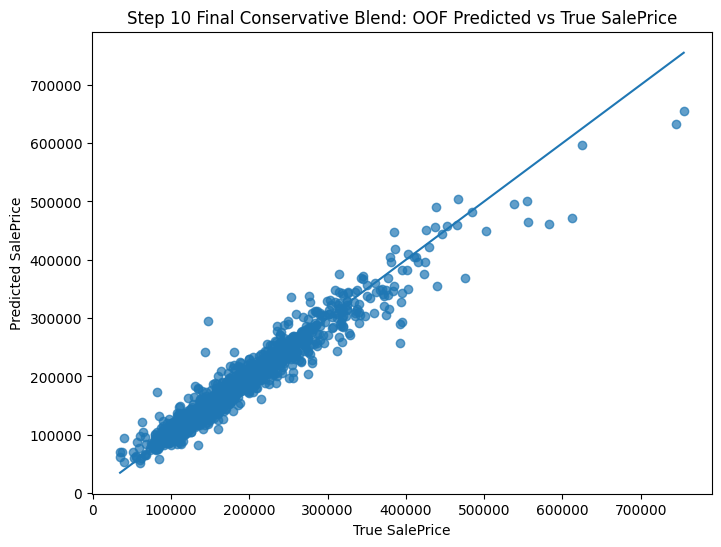

In [159]:
# Step 10.13: Plot final OOF prediction

import matplotlib.pyplot as plt

final_oof_original = np.expm1(final_blend_oof_log)
true_original = y_train_safe.copy()

plt.figure(figsize=(8, 6))

plt.scatter(
    true_original,
    final_oof_original,
    alpha=0.7
)

min_price = min(true_original.min(), final_oof_original.min())
max_price = max(true_original.max(), final_oof_original.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price]
)

plt.xlabel("True SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Step 10 Final Conservative Blend: OOF Predicted vs True SalePrice")
plt.show()

In [160]:
# Step 10.14: Final summary

step10_summary = pd.DataFrame({
    "Method": [
        "Best Single Model",
        "Inverse Weighted Blend",
        "Public Safe Blend",
        "Final Conservative Blend",
        "Tail Lift Version"
    ],
    "OOF_RMSE_log1p": [
        best_score,
        inverse_blend_rmse,
        public_safe_rmse,
        final_blend_rmse,
        tail_lift_rmse
    ]
})

step10_summary.sort_values(by="OOF_RMSE_log1p")

,Method,OOF_RMSE_log1p
4,Tail Lift Version,0.107328
1,Inverse Weighted Blend,0.107347
3,Final Conservative Blend,0.107373
2,Public Safe Blend,0.107553
0,Best Single Model,0.108330
